# 🎬 Predicting Movie Success: Estimating Weighted Rating Using Machine Learning

In this notebook, I will perform exploratory data analysis (EDA) and apply various machine learning algorithms to address the following problem:

> **Can we accurately predict the weighted rating of a movie based on its metadata, content attributes, and production details?**

The target variable for this analysis is **`weighted_rating`**, a numerical score representing the overall quality of a movie — likely derived from both user ratings and vote counts. The goal is to use all other available features (e.g., runtime, budget, genres, production companies, etc.) to build a predictive model that estimates this score **before** the movie is released.

This process will include:

* Exploratory data analysis and feature understanding
* Preprocessing and feature engineering
* Building and comparing different machine learning models
* Evaluating model performance using regression metrics
* Drawing conclusions and possible next steps

In [29]:
# Basic imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import re, time, random, datetime, math
from datetime import datetime
from tqdm import tqdm

##################### Preprocessing imports 
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from category_encoders import TargetEncoder, HashingEncoder, CountEncoder
from sklearn.impute import KNNImputer

##################### Metrics
from sklearn.metrics import make_scorer, mean_squared_error, mean_absolute_error
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

##################### Models
from xgboost import XGBClassifier, XGBRegressor
from catboost import CatBoostClassifier, CatBoostRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import make_pipeline

##################### Model selection 
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.gaussian_process.kernels import RBF, Matern, RationalQuadratic
from sklearn.model_selection import StratifiedKFold, KFold, RepeatedStratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.ensemble import VotingRegressor
from sklearn.inspection import permutation_importance
from sklearn.base import clone
from sklearn.metrics import mean_squared_error, r2_score
from scipy.optimize import minimize
from IPython.display import clear_output
from concurrent.futures import ThreadPoolExecutor
from scipy.stats import skew, kurtosis

##################### optuna library import
import optuna
import shap
import matplotlib.cm as cm
from collections import defaultdict
from currency_converter import CurrencyConverter

##################### Basic settings
random_state = 42

In [30]:
data = pd.read_csv('tmdb_movies_cleaned.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9953 entries, 0 to 9952
Data columns (total 46 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          9953 non-null   int64  
 1   title                       9953 non-null   object 
 2   runtime                     9953 non-null   int64  
 3   release_date                9953 non-null   object 
 4   budget                      9953 non-null   int64  
 5   revenue                     9953 non-null   int64  
 6   popularity                  9953 non-null   float64
 7   vote_average                9953 non-null   float64
 8   vote_count                  9953 non-null   int64  
 9   belongs_to_collection       9953 non-null   int64  
 10  has_tagline                 9953 non-null   int64  
 11  has_homepage                9953 non-null   int64  
 12  num_same_title              9953 non-null   int64  
 13  changed_title               9953 

In [31]:
data['belongs_to_collection'] = data['belongs_to_collection'].astype(bool)
data['has_tagline'] = data['has_tagline'].astype(bool)
data['has_homepage'] = data['has_homepage'].astype(bool)
data['has_homepage'] = data['has_homepage'].astype(bool)
data['release_date'] = pd.to_datetime(data['release_date'], errors='coerce')

# Extract release year (if not already present)
data['release_year'] = data['release_date'].dt.year

# Create release_decade column
data['release_decade'] = (data['release_year'] // 10) * 10

# Convert to string for categorical plotting (e.g. '1990s')
data['release_decade'] = data['release_decade'].astype('Int64').astype(str) + 's'



# Regression -> lets look at the label as numeric-consistance value (later on i will bin it and use it as catagorical)

Summary statistics for 'weighted_rating':


count    9953.000000
mean        6.442062
std         0.618833
min         3.057064
25%         6.092196
50%         6.356828
75%         6.795872
max         8.699763
Name: weighted_rating, dtype: float64

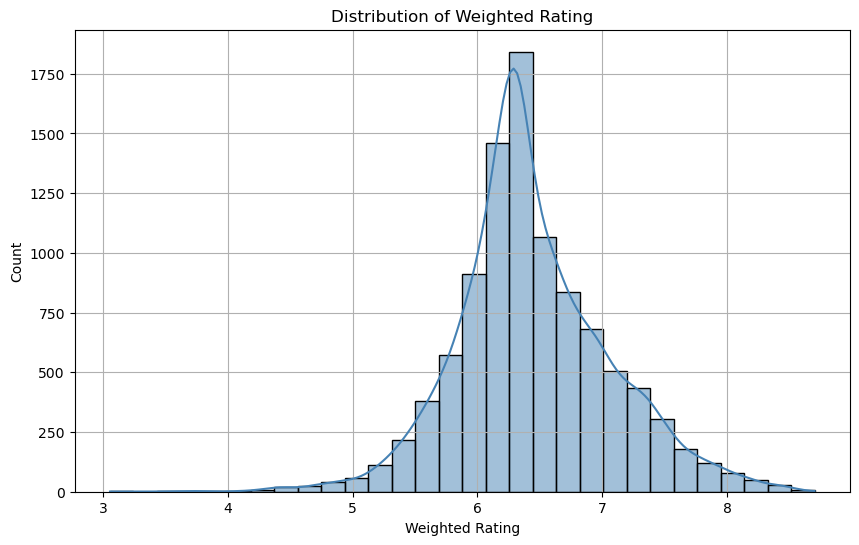

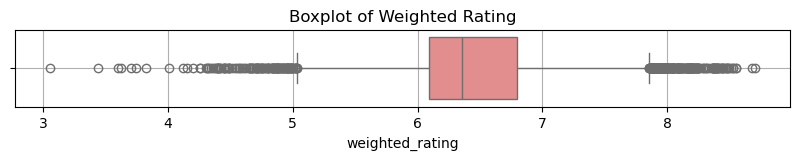

Skewness: 0.218
Kurtosis: 0.980


In [32]:
# Basic statistics
print("Summary statistics for 'weighted_rating':")
display(data['weighted_rating'].describe())

# Distribution plot
plt.figure(figsize=(10, 6))
sns.histplot(data['weighted_rating'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of Weighted Rating')
plt.xlabel('Weighted Rating')
plt.ylabel('Count')
plt.grid(True)
plt.show()

# Boxplot for outlier detection
plt.figure(figsize=(10, 1))
sns.boxplot(x=data['weighted_rating'], color='lightcoral')
plt.title('Boxplot of Weighted Rating')
plt.grid(True)
plt.show()

# Skewness and kurtosis
skewness = skew(data['weighted_rating'])
kurt = kurtosis(data['weighted_rating'])

print(f"Skewness: {skewness:.3f}")
print(f"Kurtosis: {kurt:.3f}")


## Lets find the strong corrolations between all the numeric features and our label|

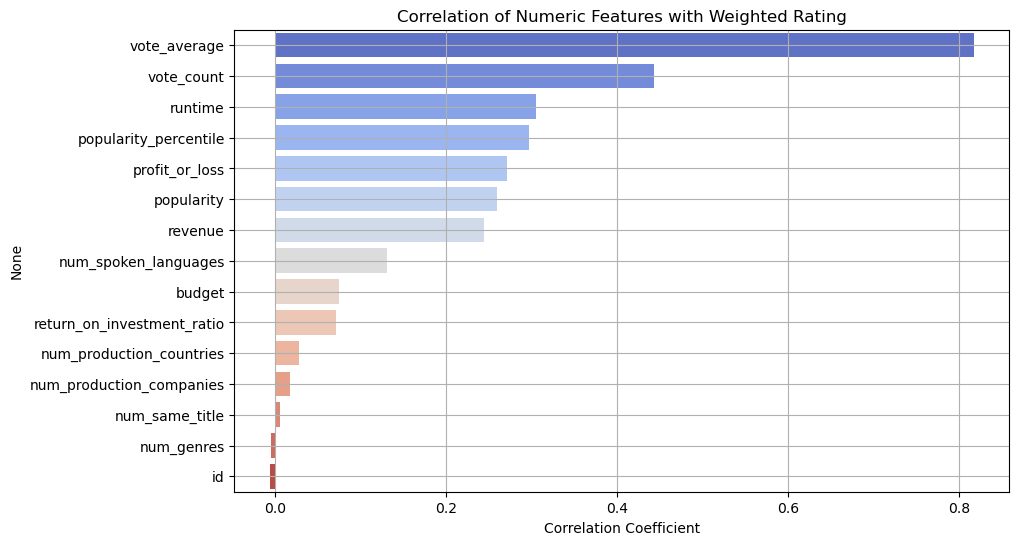

,correlation
vote_average,0.817501
vote_count,0.442431
runtime,0.304351
popularity_percentile,0.297037
profit_or_loss,0.271187
popularity,0.258900
revenue,0.244237
num_spoken_languages,0.130757
budget,0.073851
return_on_investment_ratio,0.070693


In [33]:
# Select only numerical columns (excluding the target for now)
numeric_cols = data.select_dtypes(include=['int64', 'float64']).drop(columns=['weighted_rating'])

# Compute correlation with target
correlations = numeric_cols.corrwith(data['weighted_rating']).sort_values(ascending=False)

# Plot correlation values
plt.figure(figsize=(10, 6))
sns.barplot(x=correlations.values, y=correlations.index, palette='coolwarm')
plt.title('Correlation of Numeric Features with Weighted Rating')
plt.xlabel('Correlation Coefficient')
plt.grid(True)
plt.show()

# Display top correlated features
display(correlations.to_frame(name='correlation').style.background_gradient(cmap='coolwarm'))


| Feature                 | Correlation | Notes                                                                                                         |
| ----------------------- | ----------- | ------------------------------------------------------------------------------------------------------------- |
| **`vote_average`**      | **0.82** ⚠️   | As expected — it likely feeds directly into the weighted rating formula (could be redundant or even leakage!) |
| `vote_count`            | 0.44 ✅      | More votes = more stable and possibly higher credibility                                                      |
| `runtime`               | 0.30 ✅      | Longer movies may be rated more seriously                                                                     |
| `popularity_percentile` | 0.30 ✅      | Popular movies tend to be better known and attract more attention                                             |
| `profit_or_loss`        | 0.27        | Some correlation with success, but not a strong proxy                                                         |
| `popularity`            | 0.26        | Similar to percentile, but more raw and potentially skewed                                                    |
| `revenue`               | 0.24        | Slightly correlated, but not dominant (big budgets ≠ quality)                                                 |


### As we can see our label and vote_average feature has a significantly higher corrolation. we can assume that the feature is leakage variable, because weighted_rating is often calculated as a blend of vote_average and vote_count.

## Lets explore hoe catagoric features relate to the avarage wirghted_rating

Index(['belongs_to_collection', 'has_tagline', 'has_homepage',
       'num_same_title', 'num_genres', 'Comedy', 'Action', 'Animation',
       'Drama', 'History', 'Family', 'War', 'Thriller', 'Crime', 'Adventure',
       'Music', 'Fantasy', 'Science Fiction', 'TV Movie', 'Western',
       'Documentary', 'Romance', 'Mystery', 'Horror', 'top10_prod_comps',
       'num_production_companies', 'main_production_country',
       'num_production_countries', 'num_spoken_languages', 'is_english_spoken',
       'season', 'release_decade'],
      dtype='object')

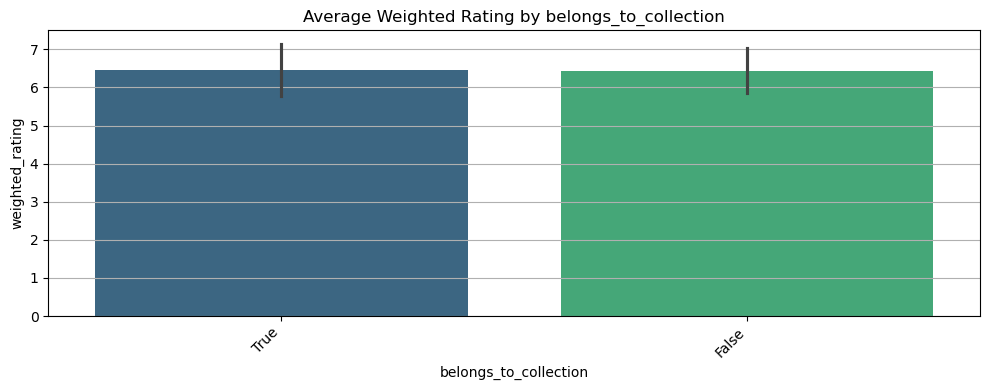

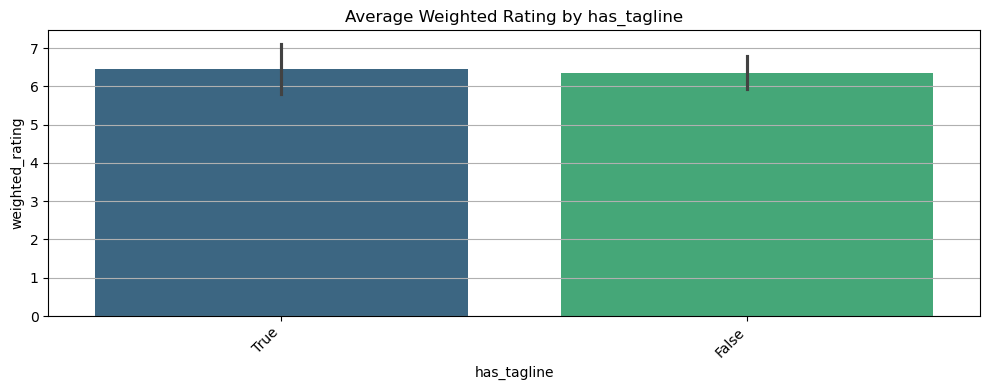

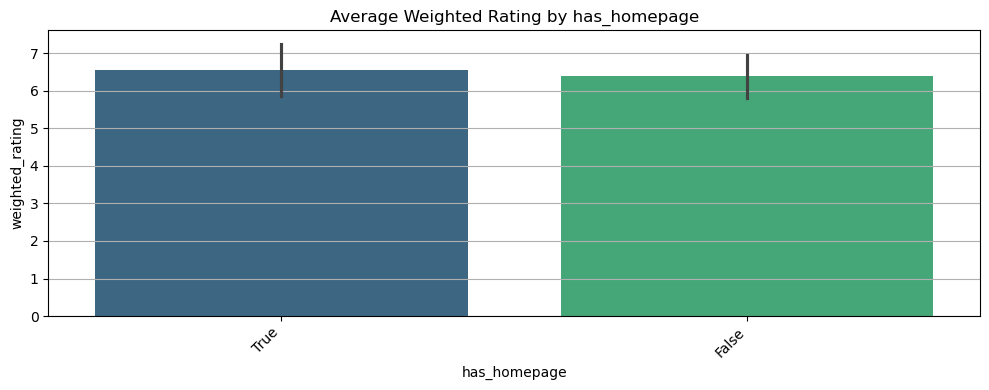

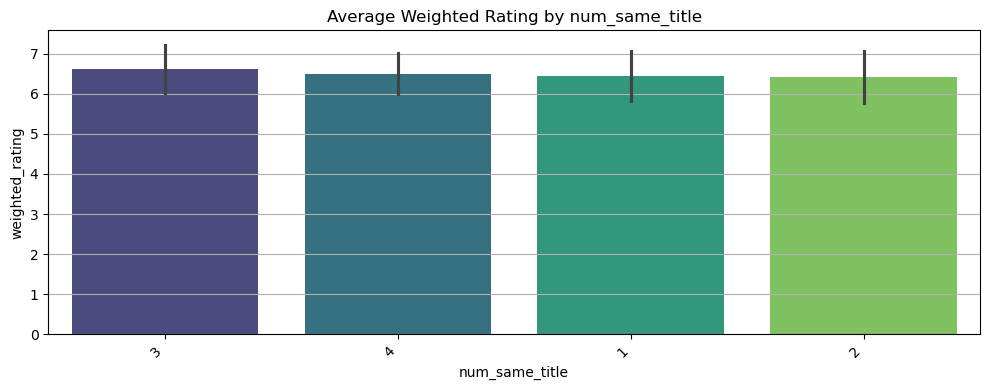

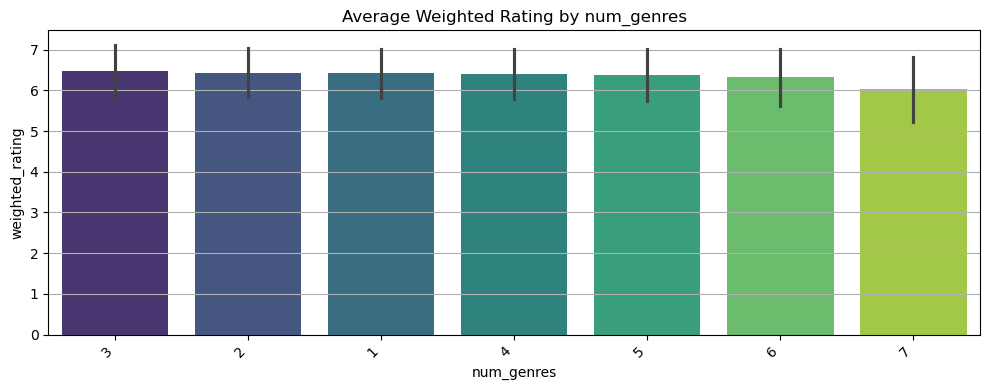

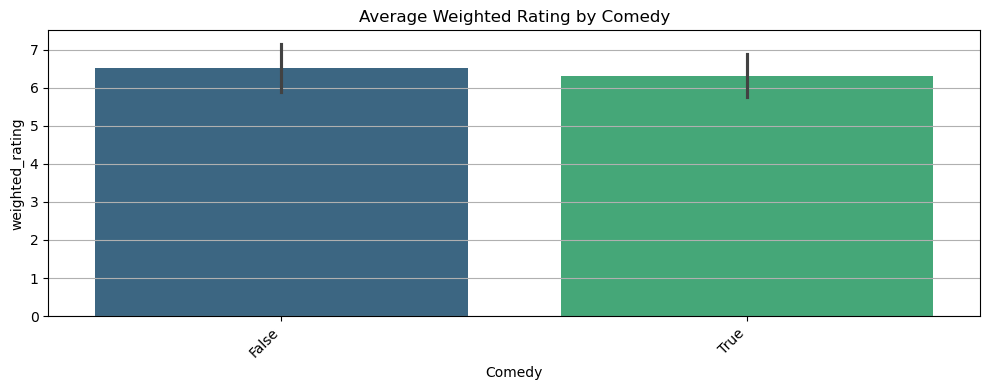

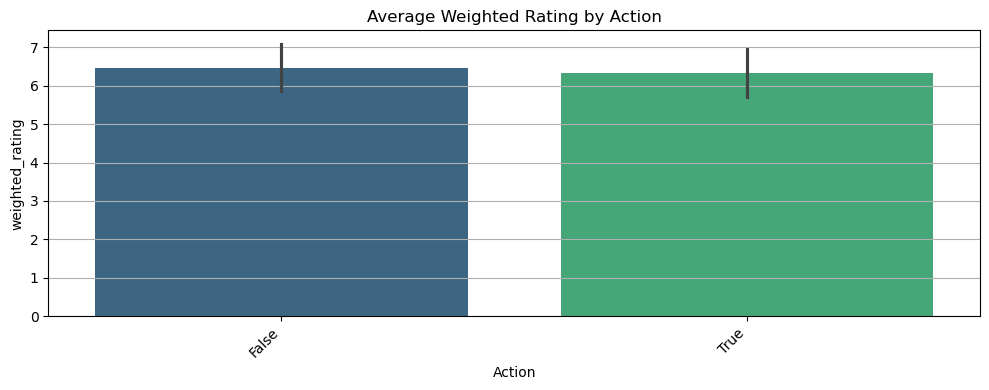

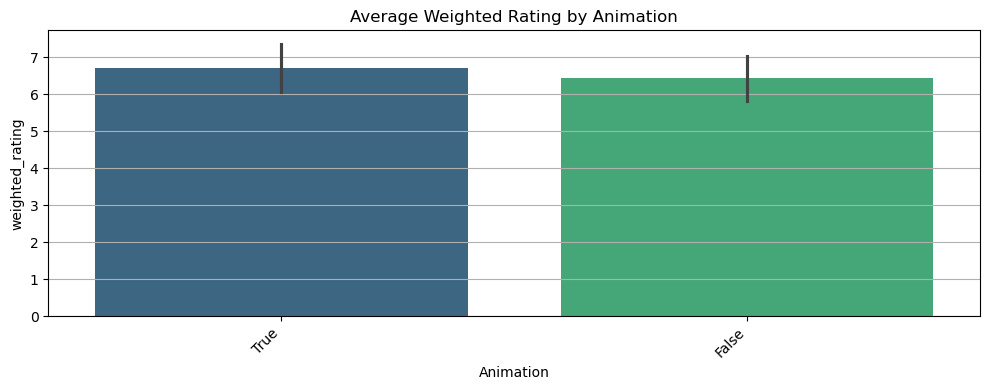

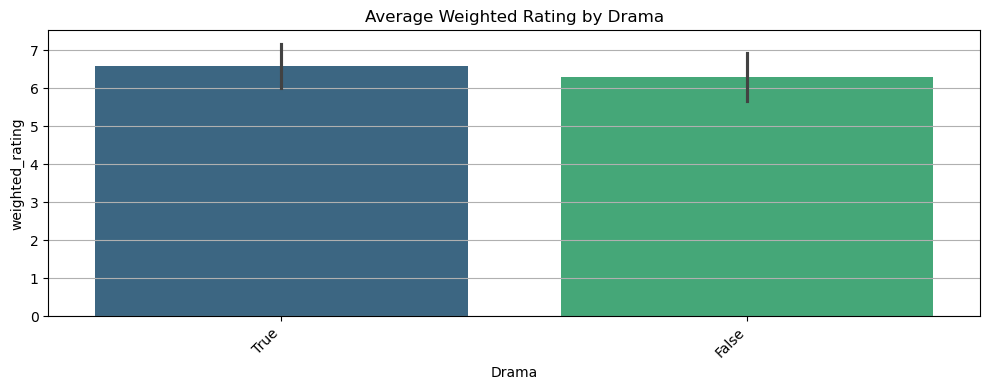

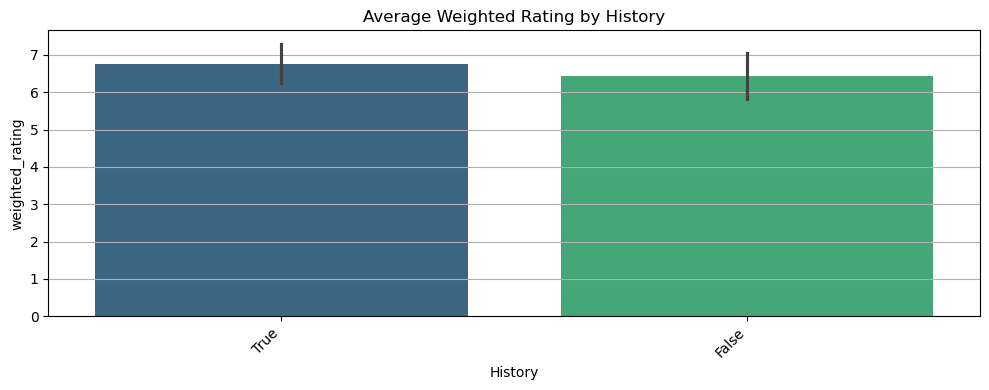

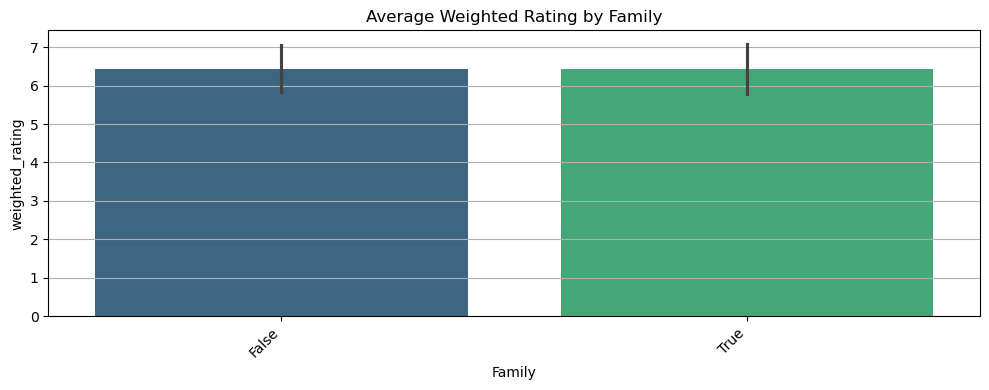

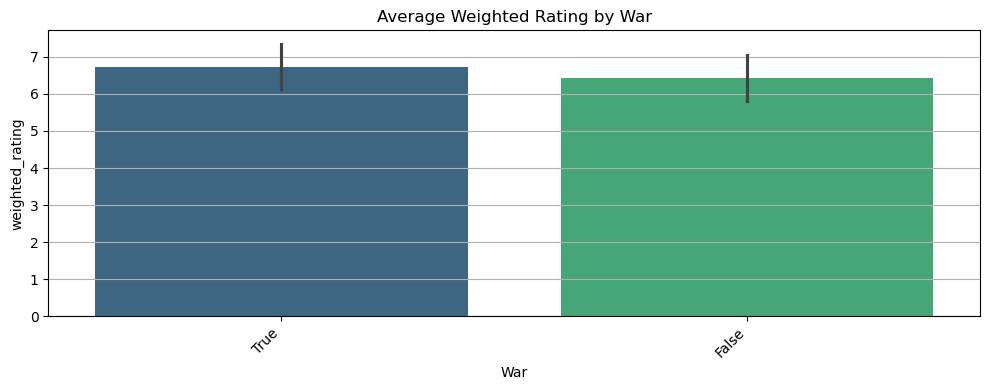

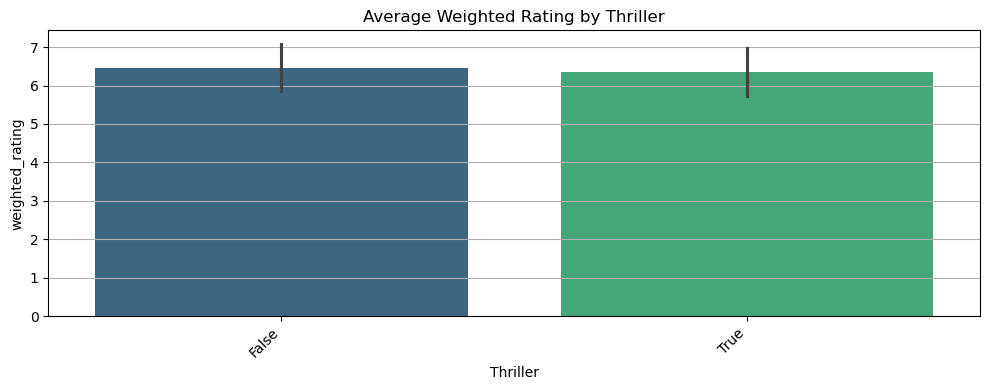

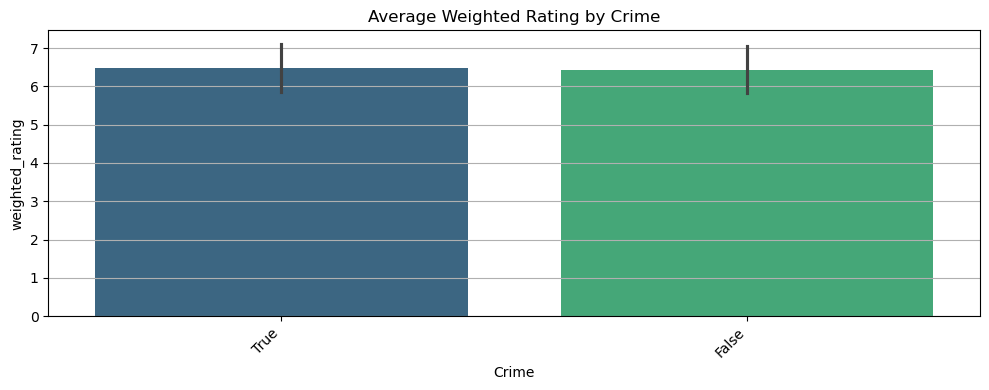

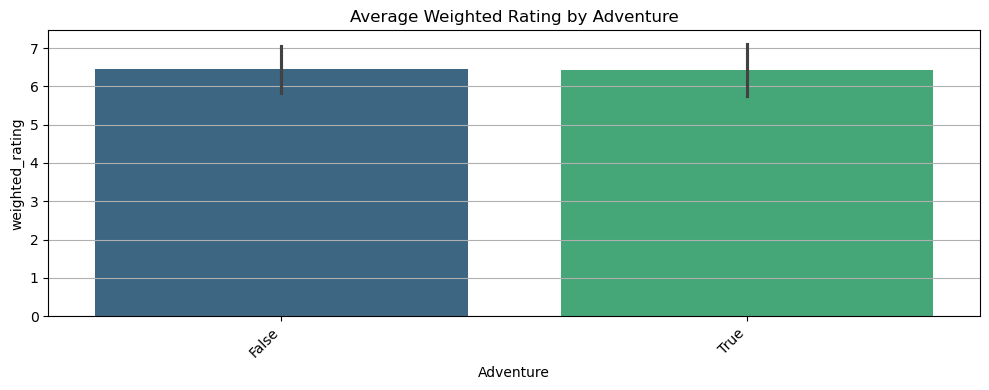

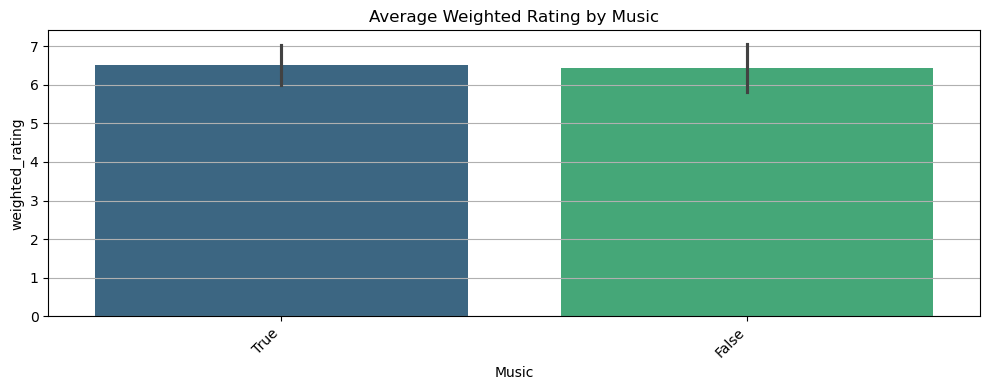

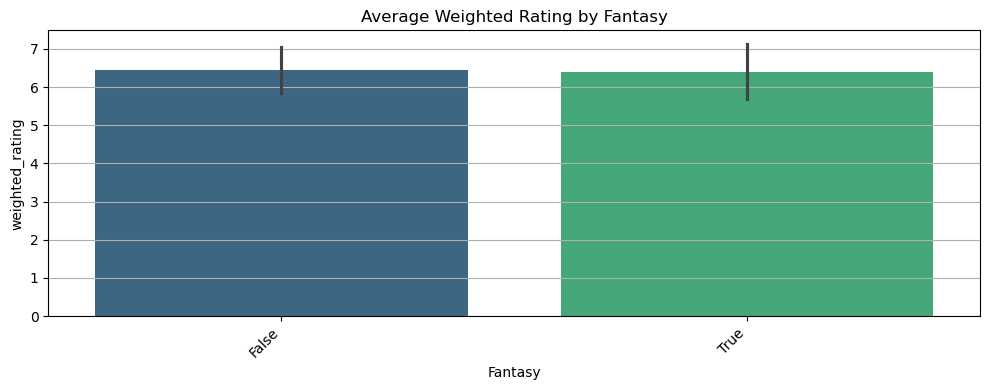

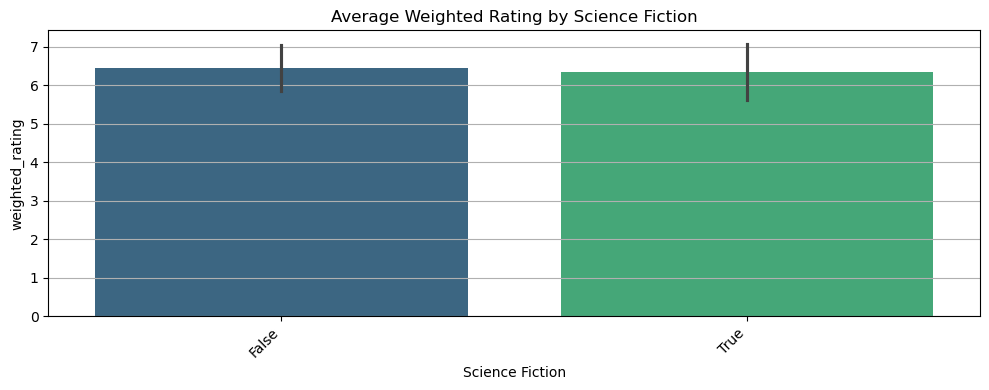

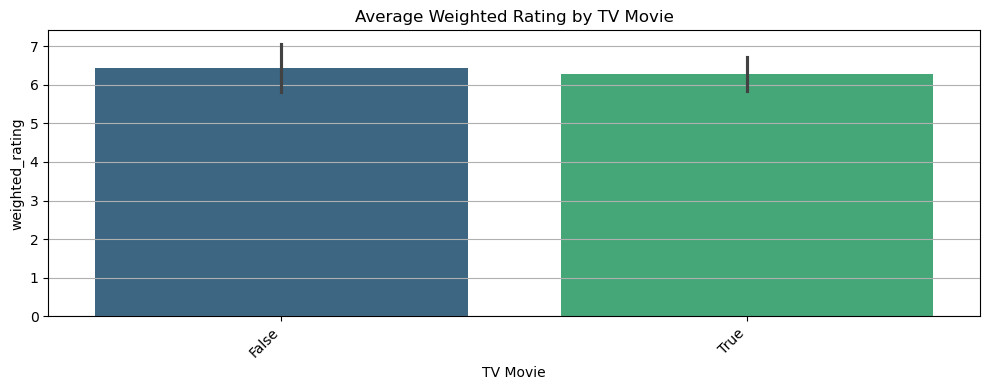

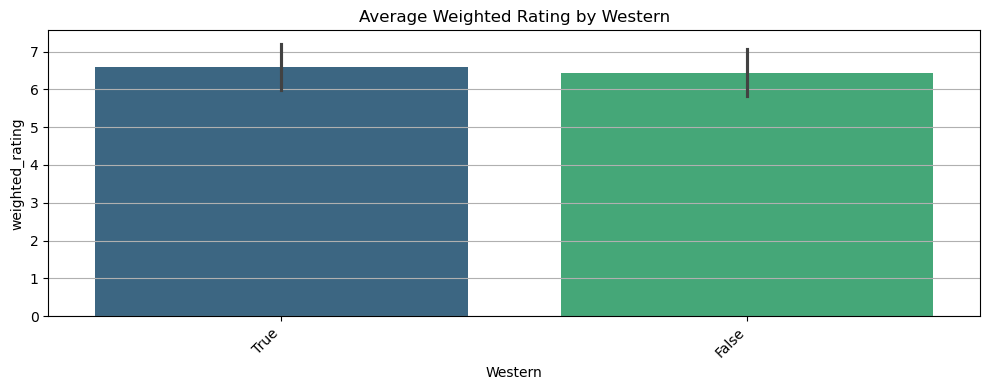

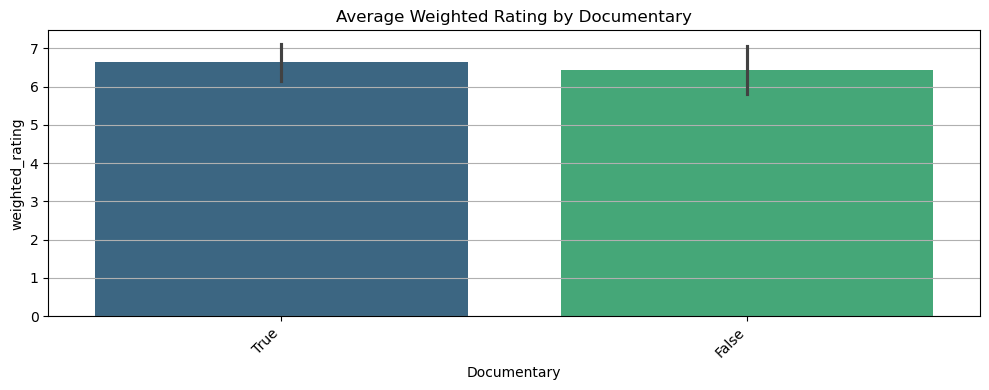

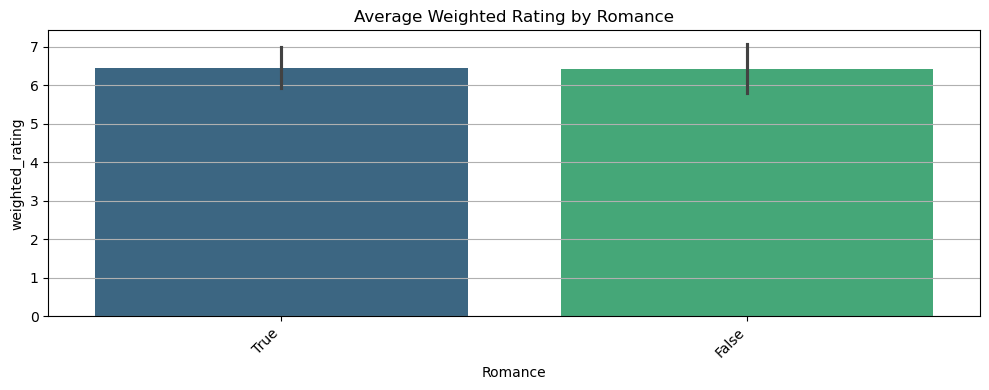

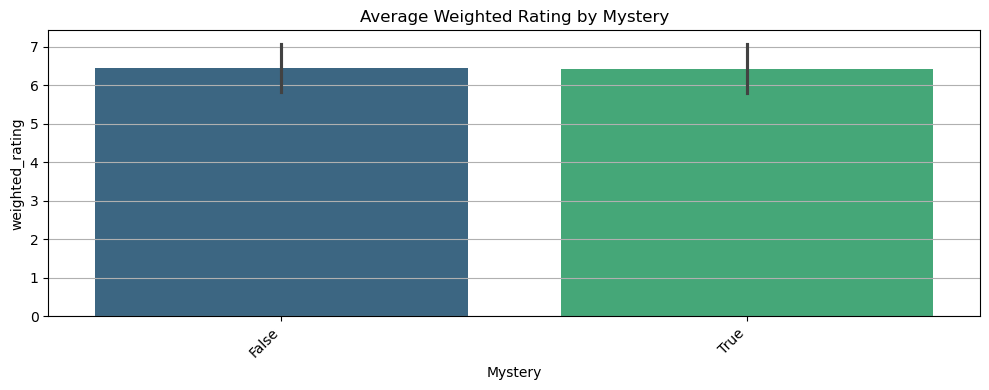

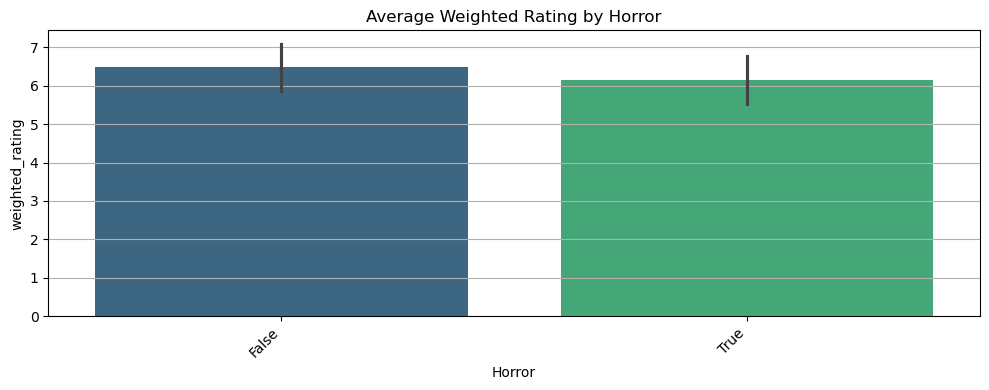

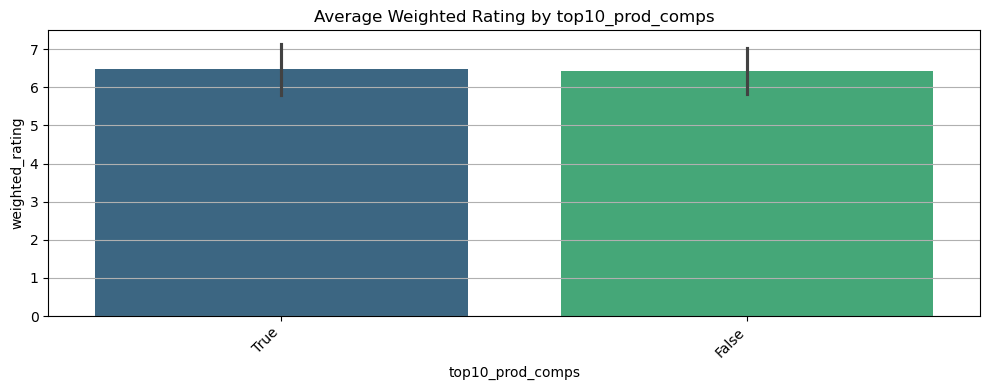

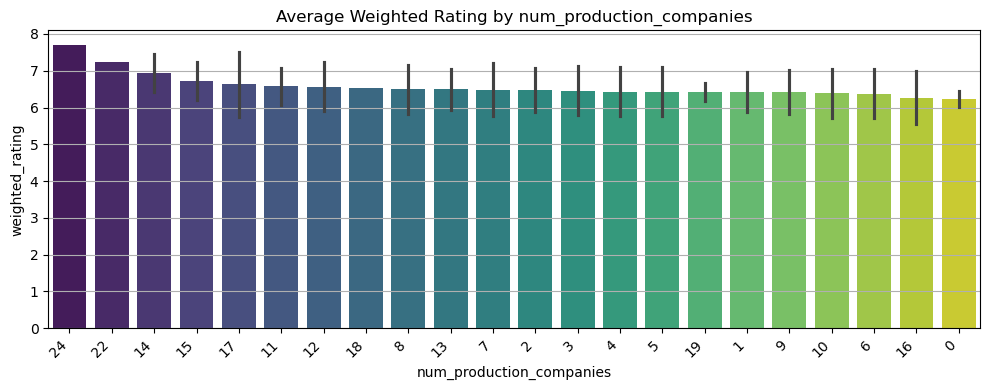

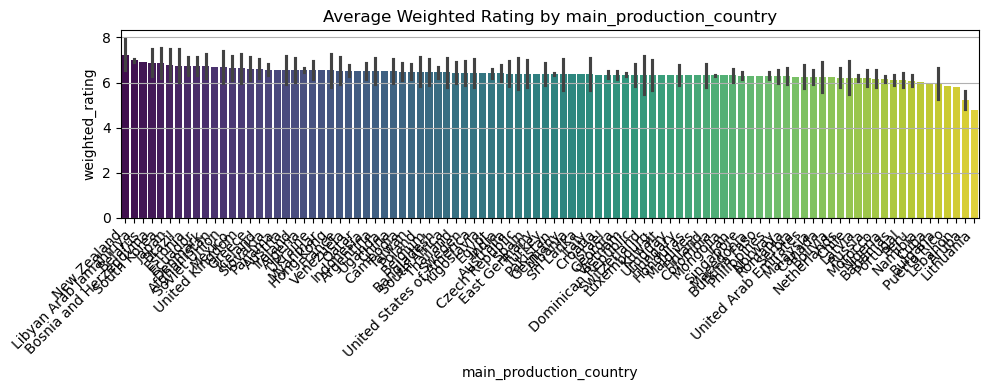

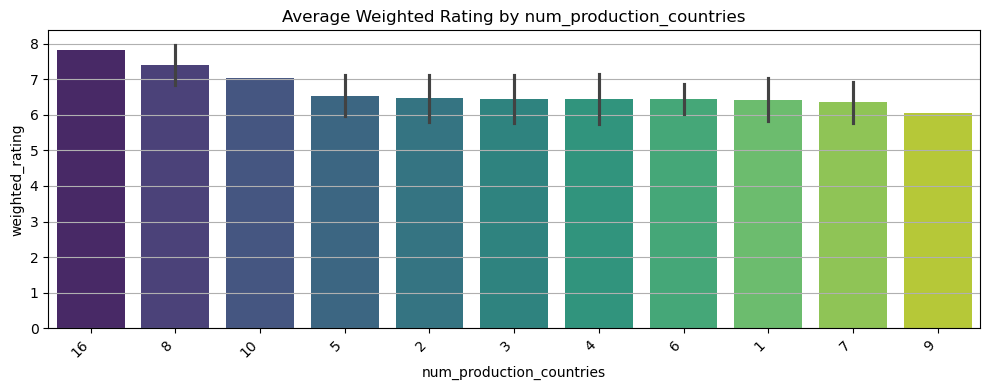

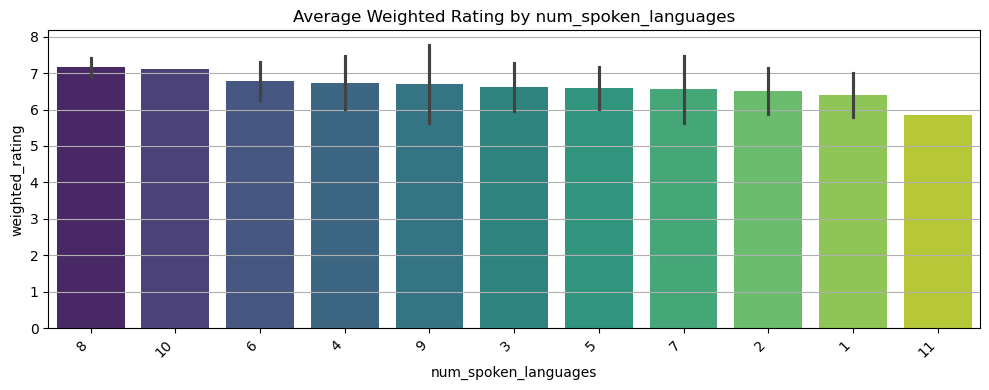

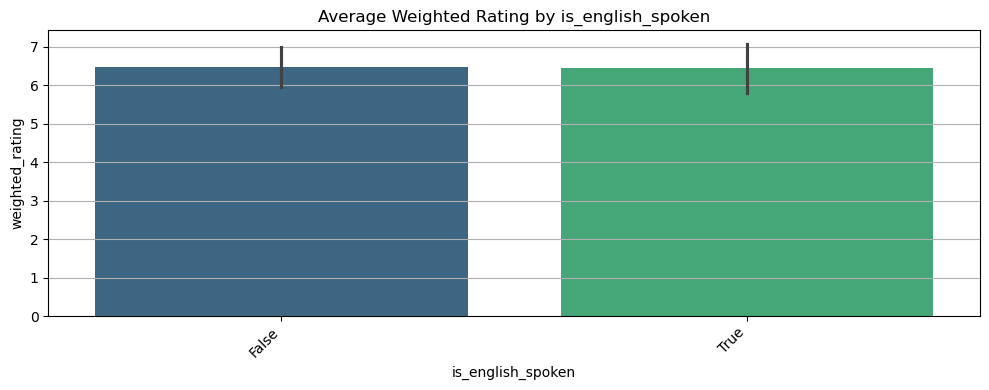

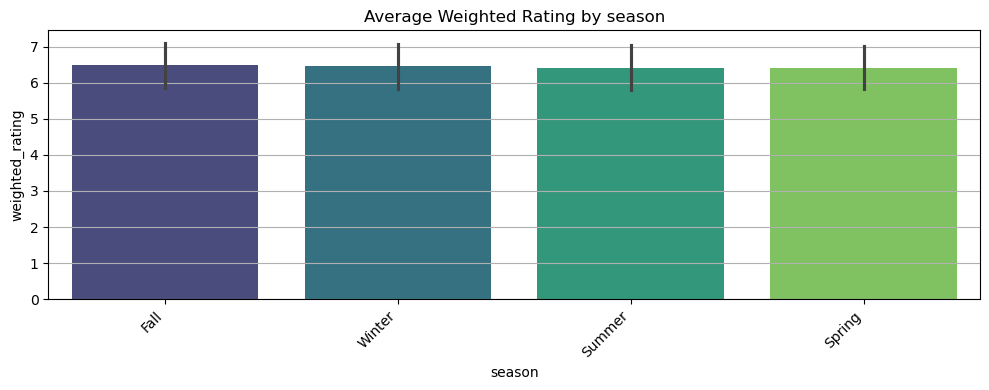

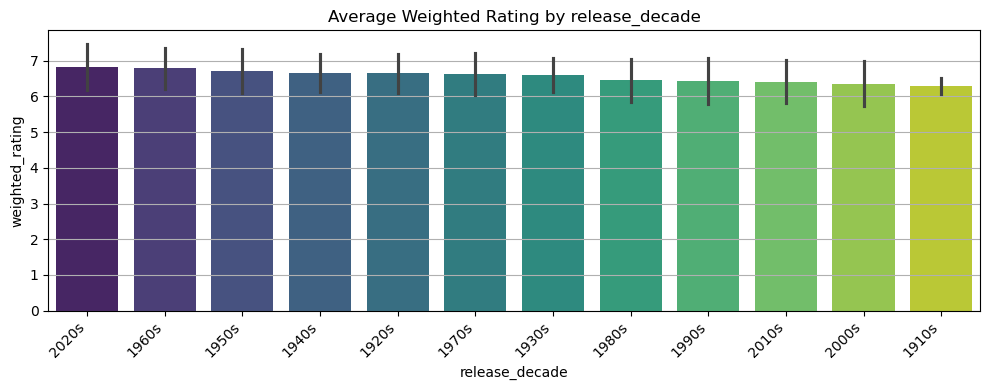

In [34]:
df_categories = data.copy()


for feature in np.array(['num_same_title', 'num_production_companies', 'num_production_countries', 'num_spoken_languages', 'num_genres']):
    df_categories[feature] = df_categories[feature].astype(object)  # Ensure these features are integers
df_categories.drop(columns=['release_date', 'release_year', 'changed_title', 'title'], inplace=True)  # Drop original date column if not needed

# Select categorical + boolean columns (excluding the target)
cat_bool_cols = df_categories.select_dtypes(include=['object', 'bool']).columns  # Include release_decade as a categorical feature
display(cat_bool_cols)

# Create a plot for each categorical feature
for col in cat_bool_cols:
    plt.figure(figsize=(10, 4))
    order = df_categories.groupby(col)['weighted_rating'].mean().sort_values(ascending=False).index
    sns.barplot(data=df_categories, x=col, y='weighted_rating', order=order, ci='sd', palette='viridis')
    plt.title(f'Average Weighted Rating by {col}')
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, axis='y')
    plt.tight_layout()
    plt.show()


### Most of the catagoric features has no effect on the wighted rating but few does:
* large no' of genres
* small no' of production companies
* small no' of production countries
* large no' of langueges

# Annomaly Detection pipeline:

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy import stats
from scipy.stats import zscore
import warnings
warnings.filterwarnings('ignore')

class MovieDataAnomalyDetector:
    """
    Comprehensive anomaly detection and data cleaning pipeline for movie dataset
    """
    
    def __init__(self, df):
        self.df = df.copy()
        self.original_shape = df.shape
        self.anomaly_reports = {}
        self.cleaned_df = None
        
    def detect_statistical_outliers(self, columns=None, z_threshold=3, iqr_multiplier=1.5):
        """
        Detect outliers using Z-score and IQR methods
        """
        if columns is None:
            # Select numeric columns for outlier detection
            numeric_cols = self.df.select_dtypes(include=[np.number]).columns
            columns = [col for col in numeric_cols if col not in ['id']]
        
        outliers_report = {}
        
        for col in columns:
            if col in self.df.columns:
                # Z-score outliers
                z_scores = np.abs(zscore(self.df[col].fillna(self.df[col].median())))
                z_outliers = self.df[z_scores > z_threshold].index.tolist()
                
                # IQR outliers
                Q1 = self.df[col].quantile(0.25)
                Q3 = self.df[col].quantile(0.75)
                IQR = Q3 - Q1
                lower_bound = Q1 - iqr_multiplier * IQR
                upper_bound = Q3 + iqr_multiplier * IQR
                iqr_outliers = self.df[(self.df[col] < lower_bound) | (self.df[col] > upper_bound)].index.tolist()
                
                outliers_report[col] = {
                    'z_score_outliers': len(z_outliers),
                    'iqr_outliers': len(iqr_outliers),
                    'z_outlier_indices': z_outliers,
                    'iqr_outlier_indices': iqr_outliers,
                    'stats': {
                        'mean': self.df[col].mean(),
                        'std': self.df[col].std(),
                        'min': self.df[col].min(),
                        'max': self.df[col].max(),
                        'Q1': Q1,
                        'Q3': Q3,
                        'IQR': IQR
                    }
                }
        
        self.anomaly_reports['statistical_outliers'] = outliers_report
        return outliers_report
    
    def detect_business_logic_anomalies(self):
        """
        Detect anomalies based on business logic and domain knowledge
        """
        anomalies = {}
        
        # 1. Movies with zero or negative budget but positive revenue
        zero_budget_positive_revenue = self.df[(self.df['budget'] <= 0) & (self.df['revenue'] > 0)]
        anomalies['zero_budget_positive_revenue'] = {
            'count': len(zero_budget_positive_revenue),
            'indices': zero_budget_positive_revenue.index.tolist()
        }
        
        # 2. Movies with budget > revenue but positive ROI
        budget_revenue_roi_mismatch = self.df[
            (self.df['budget'] > self.df['revenue']) & 
            (self.df['return_on_investment_ratio'] > 1)
        ]
        anomalies['budget_revenue_roi_mismatch'] = {
            'count': len(budget_revenue_roi_mismatch),
            'indices': budget_revenue_roi_mismatch.index.tolist()
        }
        
        # 3. Movies with extremely high ratings but very low vote counts
        high_rating_low_votes = self.df[
            (self.df['vote_average'] > 8.5) & 
            (self.df['vote_count'] < 10)
        ]
        anomalies['high_rating_low_votes'] = {
            'count': len(high_rating_low_votes),
            'indices': high_rating_low_votes.index.tolist()
        }
        
        # 4. Movies with runtime anomalies (too short or too long)
        runtime_anomalies = self.df[
            (self.df['runtime'] < 30) | (self.df['runtime'] > 300)
        ]
        anomalies['runtime_anomalies'] = {
            'count': len(runtime_anomalies),
            'indices': runtime_anomalies.index.tolist()
        }
        
        # 5. Movies with impossible release dates (future dates beyond reasonable range)
        current_year = 2024
        future_movies = self.df[self.df['release_year'] > current_year + 2]
        anomalies['future_movies'] = {
            'count': len(future_movies),
            'indices': future_movies.index.tolist()
        }
        
        # 6. Movies with weighted_rating outside expected range
        rating_range_anomalies = self.df[
            (self.df['weighted_rating'] < 0) | (self.df['weighted_rating'] > 10)
        ]
        anomalies['rating_range_anomalies'] = {
            'count': len(rating_range_anomalies),
            'indices': rating_range_anomalies.index.tolist()
        }
        
        self.anomaly_reports['business_logic_anomalies'] = anomalies
        return anomalies
    
    def detect_multivariate_outliers(self, features=None, contamination=0.1):
        """
        Detect multivariate outliers using Isolation Forest
        """
        if features is None:
            # Select key numeric features for multivariate analysis
            features = ['budget', 'revenue', 'popularity', 'vote_average', 'vote_count', 
                       'runtime', 'weighted_rating', 'return_on_investment_ratio']
        
        # Prepare data for Isolation Forest
        feature_data = self.df[features].fillna(self.df[features].median())
        
        # Standardize features
        scaler = StandardScaler()
        scaled_features = scaler.fit_transform(feature_data)
        
        # Apply Isolation Forest
        iso_forest = IsolationForest(contamination=contamination, random_state=42)
        outlier_labels = iso_forest.fit_predict(scaled_features)
        
        # Get outlier indices
        outlier_indices = self.df[outlier_labels == -1].index.tolist()
        
        multivariate_report = {
            'total_outliers': len(outlier_indices),
            'outlier_indices': outlier_indices,
            'outlier_percentage': (len(outlier_indices) / len(self.df)) * 100,
            'features_used': features
        }
        
        self.anomaly_reports['multivariate_outliers'] = multivariate_report
        return multivariate_report
    
    def detect_data_quality_issues(self):
        """
        Detect data quality issues like duplicates, inconsistencies
        """
        quality_issues = {}
        
        # 1. Check for duplicate movies (same title, release_year, runtime)
        duplicate_movies = self.df.duplicated(subset=['title', 'release_year', 'runtime'], keep=False)
        quality_issues['duplicate_movies'] = {
            'count': duplicate_movies.sum(),
            'indices': self.df[duplicate_movies].index.tolist()
        }
        
        # 2. Check for inconsistent genre information
        genre_cols = ['Comedy', 'Action', 'Animation', 'Drama', 'History', 'Family', 
                     'War', 'Thriller', 'Crime', 'Adventure', 'Music', 'Fantasy', 
                     'Science Fiction', 'TV Movie', 'Western', 'Documentary', 'Romance', 
                     'Mystery', 'Horror']
        
        actual_genre_count = self.df[genre_cols].sum(axis=1)
        genre_inconsistency = self.df[actual_genre_count != self.df['num_genres']]
        quality_issues['genre_count_mismatch'] = {
            'count': len(genre_inconsistency),
            'indices': genre_inconsistency.index.tolist()
        }
        
        # 3. Check for movies with no genres
        no_genre_movies = self.df[self.df['num_genres'] == 0]
        quality_issues['no_genre_movies'] = {
            'count': len(no_genre_movies),
            'indices': no_genre_movies.index.tolist()
        }
        
        self.anomaly_reports['data_quality_issues'] = quality_issues
        return quality_issues
    
    def generate_anomaly_summary(self):
        """
        Generate comprehensive anomaly detection summary
        """
        print("=== ANOMALY DETECTION SUMMARY ===")
        print(f"Original dataset shape: {self.original_shape}")
        print(f"Total records: {len(self.df)}")
        print()
        
        # Statistical outliers summary
        if 'statistical_outliers' in self.anomaly_reports:
            print("📊 STATISTICAL OUTLIERS:")
            for col, report in self.anomaly_reports['statistical_outliers'].items():
                print(f"  {col}:")
                print(f"    - Z-score outliers: {report['z_score_outliers']}")
                print(f"    - IQR outliers: {report['iqr_outliers']}")
            print()
        
        # Business logic anomalies summary
        if 'business_logic_anomalies' in self.anomaly_reports:
            print("🔍 BUSINESS LOGIC ANOMALIES:")
            for anomaly_type, report in self.anomaly_reports['business_logic_anomalies'].items():
                print(f"  {anomaly_type}: {report['count']} records")
            print()
        
        # Multivariate outliers summary
        if 'multivariate_outliers' in self.anomaly_reports:
            print("🎯 MULTIVARIATE OUTLIERS:")
            report = self.anomaly_reports['multivariate_outliers']
            print(f"  Total outliers: {report['total_outliers']} ({report['outlier_percentage']:.2f}%)")
            print()
        
        # Data quality issues summary
        if 'data_quality_issues' in self.anomaly_reports:
            print("⚠️  DATA QUALITY ISSUES:")
            for issue_type, report in self.anomaly_reports['data_quality_issues'].items():
                print(f"  {issue_type}: {report['count']} records")
            print()
    
    def clean_data(self, strategy='conservative'):
        """
        Clean the dataset based on detected anomalies
        
        Parameters:
        strategy: 'conservative', 'moderate', or 'aggressive'
        """
        self.cleaned_df = self.df.copy()
        removal_log = {}
        
        if strategy == 'conservative':
            # Only remove clear data quality issues
            indices_to_remove = set()
            
            # Remove duplicates
            if 'data_quality_issues' in self.anomaly_reports:
                duplicate_indices = self.anomaly_reports['data_quality_issues']['duplicate_movies']['indices']
                # Keep first occurrence of duplicates
                df_temp = self.cleaned_df.iloc[duplicate_indices]
                duplicates_to_remove = df_temp.duplicated(subset=['title', 'release_year', 'runtime'], keep='first')
                indices_to_remove.update(df_temp[duplicates_to_remove].index.tolist())
                removal_log['duplicates'] = len(df_temp[duplicates_to_remove])
            
            # Remove impossible ratings
            if 'business_logic_anomalies' in self.anomaly_reports:
                rating_anomalies = self.anomaly_reports['business_logic_anomalies']['rating_range_anomalies']['indices']
                indices_to_remove.update(rating_anomalies)
                removal_log['rating_range_anomalies'] = len(rating_anomalies)
        
        elif strategy == 'moderate':
            # Remove data quality issues + obvious business logic anomalies
            indices_to_remove = set()
            
            # All conservative removals
            if 'data_quality_issues' in self.anomaly_reports:
                for issue_type, report in self.anomaly_reports['data_quality_issues'].items():
                    if issue_type == 'duplicate_movies':
                        df_temp = self.cleaned_df.iloc[report['indices']]
                        duplicates_to_remove = df_temp.duplicated(subset=['title', 'release_year', 'runtime'], keep='first')
                        indices_to_remove.update(df_temp[duplicates_to_remove].index.tolist())
                    else:
                        indices_to_remove.update(report['indices'])
                removal_log['data_quality_issues'] = len(indices_to_remove)
            
            # Business logic anomalies
            if 'business_logic_anomalies' in self.anomaly_reports:
                for anomaly_type in ['rating_range_anomalies', 'future_movies', 'runtime_anomalies']:
                    if anomaly_type in self.anomaly_reports['business_logic_anomalies']:
                        anomaly_indices = self.anomaly_reports['business_logic_anomalies'][anomaly_type]['indices']
                        indices_to_remove.update(anomaly_indices)
                        removal_log[anomaly_type] = len(anomaly_indices)
        
        elif strategy == 'aggressive':
            # Remove all detected anomalies
            indices_to_remove = set()
            
            # All moderate removals
            if 'data_quality_issues' in self.anomaly_reports:
                for issue_type, report in self.anomaly_reports['data_quality_issues'].items():
                    if issue_type == 'duplicate_movies':
                        df_temp = self.cleaned_df.iloc[report['indices']]
                        duplicates_to_remove = df_temp.duplicated(subset=['title', 'release_year', 'runtime'], keep='first')
                        indices_to_remove.update(df_temp[duplicates_to_remove].index.tolist())
                    else:
                        indices_to_remove.update(report['indices'])
            
            if 'business_logic_anomalies' in self.anomaly_reports:
                for anomaly_type, report in self.anomaly_reports['business_logic_anomalies'].items():
                    indices_to_remove.update(report['indices'])
                    removal_log[anomaly_type] = len(report['indices'])
            
            # Add multivariate outliers
            if 'multivariate_outliers' in self.anomaly_reports:
                outlier_indices = self.anomaly_reports['multivariate_outliers']['outlier_indices']
                indices_to_remove.update(outlier_indices)
                removal_log['multivariate_outliers'] = len(outlier_indices)
        
        # Remove identified anomalies
        if indices_to_remove:
            self.cleaned_df = self.cleaned_df.drop(indices_to_remove)
            self.cleaned_df = self.cleaned_df.reset_index(drop=True)
        
        print(f"=== DATA CLEANING SUMMARY ({strategy.upper()} STRATEGY) ===")
        print(f"Original records: {len(self.df)}")
        print(f"Records removed: {len(indices_to_remove)}")
        print(f"Final records: {len(self.cleaned_df)}")
        print(f"Removal percentage: {(len(indices_to_remove) / len(self.df)) * 100:.2f}%")
        print()
        print("Removal breakdown:")
        for reason, count in removal_log.items():
            print(f"  {reason}: {count}")
        print()
        
        return self.cleaned_df
    
    def visualize_anomalies(self, figsize=(15, 12)):
        """
        Create visualizations for detected anomalies
        """
        fig, axes = plt.subplots(2, 3, figsize=figsize)
        fig.suptitle('Anomaly Detection Visualizations', fontsize=16)
        
        # 1. Distribution of key features with outliers highlighted
        features_to_plot = ['budget', 'revenue', 'popularity', 'vote_average', 'weighted_rating', 'runtime']
        
        for i, feature in enumerate(features_to_plot):
            row = i // 3
            col = i % 3
            
            # Plot distribution
            axes[row, col].hist(self.df[feature], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
            axes[row, col].set_title(f'{feature} Distribution')
            axes[row, col].set_xlabel(feature)
            axes[row, col].set_ylabel('Frequency')
            
            # Highlight outliers if detected
            if 'statistical_outliers' in self.anomaly_reports and feature in self.anomaly_reports['statistical_outliers']:
                outlier_indices = self.anomaly_reports['statistical_outliers'][feature]['iqr_outlier_indices']
                if outlier_indices:
                    outlier_values = self.df.loc[outlier_indices, feature]
                    axes[row, col].axvline(outlier_values.min(), color='red', linestyle='--', alpha=0.7, label='Outlier Range')
                    axes[row, col].axvline(outlier_values.max(), color='red', linestyle='--', alpha=0.7)
                    axes[row, col].legend()
        
        plt.tight_layout()
        plt.show()
        
        # 2. Correlation matrix to identify unusual relationships
        numeric_cols = self.df.select_dtypes(include=[np.number]).columns
        correlation_matrix = self.df[numeric_cols].corr()
        
        plt.figure(figsize=(12, 10))
        sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
                   square=True, fmt='.2f', cbar_kws={'label': 'Correlation'})
        plt.title('Feature Correlation Matrix')
        plt.tight_layout()
        plt.show()
    
    def run_complete_pipeline(self, cleaning_strategy='moderate'):
        """
        Run the complete anomaly detection and cleaning pipeline
        """
        print("🚀 Starting Anomaly Detection Pipeline...")
        print()
        
        # Step 1: Detect statistical outliers
        print("Step 1: Detecting statistical outliers...")
        self.detect_statistical_outliers()
        
        # Step 2: Detect business logic anomalies
        print("Step 2: Detecting business logic anomalies...")
        self.detect_business_logic_anomalies()
        
        # Step 3: Detect multivariate outliers
        print("Step 3: Detecting multivariate outliers...")
        self.detect_multivariate_outliers()
        
        # Step 4: Detect data quality issues
        print("Step 4: Detecting data quality issues...")
        self.detect_data_quality_issues()
        
        # Step 5: Generate summary
        print("Step 5: Generating anomaly summary...")
        self.generate_anomaly_summary()
        
        # Step 6: Clean data
        print("Step 6: Cleaning data...")
        cleaned_data = self.clean_data(strategy=cleaning_strategy)
        
        # Step 7: Visualize anomalies
        print("Step 7: Creating visualizations...")
        self.visualize_anomalies()
        
        print("✅ Anomaly detection pipeline completed!")
        return cleaned_data, self.anomaly_reports

# Classification pipeline:

In [65]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

class MovieRatingClassifier:
    """
    A comprehensive pipeline for multi-class classification of movie ratings.
    """
    def __init__(self, df):
        self.df = df.copy()
        self.X = None
        self.y = None
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        self.preprocessor = None
        self.models = {}
        self.results = {}
        self.class_names = []

    def preprocess_data(self, target_col='weighted_rating', test_size=0.2, random_state=42):
        """
        Preprocesses data for classification: bins the target, defines features,
        and creates a preprocessing pipeline for scaling and encoding.
        """
        print("🔄 Starting data preprocessing for classification...")

        # Bin the target variable to create classes
        self.df['rating_category'] = pd.qcut(self.df[target_col], q=4, labels=False, duplicates='drop')
        self.y = self.df['rating_category']
        self.class_names = [str(c) for c in sorted(self.y.unique())] # Store class names for plots

        # Define features X by selecting all columns except the ones to be dropped.
        # This is a more robust method than using df.drop(), which was causing an error.
        columns_to_drop = [target_col, 'rating_category', 'id', 'title', 'release_date']
        features_to_keep = [col for col in self.df.columns if col not in columns_to_drop]
        self.X = self.df[features_to_keep]

        # Identify column types
        numerical_features = self.X.select_dtypes(include=np.number).columns.tolist()
        categorical_features = self.X.select_dtypes(include=['object', 'bool']).columns.tolist()
        print(f"📊 Identified {len(categorical_features)} categorical and {len(numerical_features)} numerical features.")

        # Create a column transformer for preprocessing
        self.preprocessor = ColumnTransformer(transformers=[
            ('num', StandardScaler(), numerical_features),
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
        ])

        # Split the data with stratification
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X, self.y, test_size=test_size, random_state=random_state, stratify=self.y
        )
        
        print("✅ Preprocessing complete!")
        print(f"📈 Training set: {self.X_train.shape[0]} samples")
        print(f"📉 Test set: {self.X_test.shape[0]} samples")
        print(f"🎯 Features: {self.X_train.shape[1]} columns")
        print(f"🏷️ Target classes: {len(self.class_names)}")

        return self

    def train_baseline_models(self):
        """
        Trains and evaluates a suite of industry-standard classification models.
        """
        print("\n🤖 Training baseline classification models...")

        # Define baseline classifiers
        baseline_models = {
            'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
            'K-Nearest Neighbors': KNeighborsClassifier(),
            'SVC': SVC(random_state=42, probability=True),
            'Random Forest': RandomForestClassifier(random_state=42),
            'Gradient Boosting': GradientBoostingClassifier(random_state=42),
            'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss'),
            'LightGBM': LGBMClassifier(random_state=42, verbosity=-1),
            'CatBoost': CatBoostClassifier(random_state=42, verbose=False)
        }

        for name, model in baseline_models.items():
            print(f"Training {name}...")
            
            # Create a pipeline with preprocessing and the model
            pipeline = Pipeline(steps=[('preprocessor', self.preprocessor), ('classifier', model)])
            
            # Train model
            pipeline.fit(self.X_train, self.y_train)
            
            # Make predictions
            y_pred_test = pipeline.predict(self.X_test)
            y_pred_proba_test = pipeline.predict_proba(self.X_test) if hasattr(pipeline, "predict_proba") else None
            
            # Calculate metrics
            accuracy = accuracy_score(self.y_test, y_pred_test)
            f1 = f1_score(self.y_test, y_pred_test, average='weighted')
            
            # Store results
            self.results[name] = {
                'model': pipeline,
                'accuracy': accuracy,
                'f1_score': f1,
                'predictions': y_pred_test,
                'predict_proba': y_pred_proba_test
            }
            
            print(f"  ✅ Test Accuracy: {accuracy:.4f}, Test F1-Score: {f1:.4f}")
        
        return self
    
    def evaluate_models(self):
        """
        Provides a summary of model performance and identifies the best model.
        """
        print("\n📊 Model Evaluation Summary")
        print("=" * 80)
        
        results_df = pd.DataFrame({
            'Model': list(self.results.keys()),
            'Accuracy': [self.results[model]['accuracy'] for model in self.results.keys()],
            'F1_Score': [self.results[model]['f1_score'] for model in self.results.keys()]
        }).sort_values('F1_Score', ascending=False).reset_index(drop=True)
        
        print(results_df.round(4))
        
        best_model_name = results_df.iloc[0]['Model']
        best_model_f1 = results_df.iloc[0]['F1_Score']
        
        print(f"\n🏆 Best Model (by F1-Score): {best_model_name}")
        print(f"🎯 Best Test F1-Score: {best_model_f1:.4f}\n")

        print("Classification Report for Best Model:")
        print(classification_report(self.y_test, self.results[best_model_name]['predictions'], target_names=self.class_names))
        
        return results_df, best_model_name

    def plot_results(self):
        """
        Visualizes model performance with classification-specific plots.
        """
        if not self.results:
            print("No models trained yet. Please run `train_baseline_models` first.")
            return

        fig, axes = plt.subplots(2, 2, figsize=(18, 16))
        fig.suptitle('Classification Model Performance Analysis', fontsize=20)
        
        models = list(self.results.keys())
        f1_scores = [self.results[model]['f1_score'] for model in models]
        accuracy_scores = [self.results[model]['accuracy'] for model in models]
        
        best_model_name = max(self.results, key=lambda name: self.results[name]['f1_score'])

        # 1. Model F1-Score comparison
        sns.barplot(ax=axes[0, 0], x=f1_scores, y=models, palette='viridis', orient='h')
        axes[0, 0].set_xlabel('F1-Score (Weighted)', fontsize=12)
        axes[0, 0].set_title('Model F1-Score Comparison', fontsize=14)
        axes[0, 0].grid(axis='x', linestyle='--', alpha=0.6)

        # 2. Model Accuracy comparison
        sns.barplot(ax=axes[0, 1], x=accuracy_scores, y=models, palette='plasma', orient='h')
        axes[0, 1].set_xlabel('Accuracy Score', fontsize=12)
        axes[0, 1].set_title('Model Accuracy Comparison', fontsize=14)
        axes[0, 1].grid(axis='x', linestyle='--', alpha=0.6)

        # 3. Confusion Matrix for the best model
        cm = confusion_matrix(self.y_test, self.results[best_model_name]['predictions'])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0], 
                    xticklabels=self.class_names, yticklabels=self.class_names)
        axes[1, 0].set_title(f'Confusion Matrix - {best_model_name}', fontsize=14)
        axes[1, 0].set_xlabel('Predicted Label', fontsize=12)
        axes[1, 0].set_ylabel('True Label', fontsize=12)

        # 4. ROC Curve for the best model (One-vs-Rest)
        y_pred_proba = self.results[best_model_name]['predict_proba']
        if y_pred_proba is not None:
            # Binarize the output
            y_test_bin = OneHotEncoder(sparse_output=False).fit_transform(self.y_test.values.reshape(-1, 1))
            
            fpr = dict()
            tpr = dict()
            roc_auc = dict()
            for i in range(len(self.class_names)):
                fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
                roc_auc[i] = auc(fpr[i], tpr[i])
            
            colors = sns.color_palette('Set1', n_colors=len(self.class_names))
            for i, color in zip(range(len(self.class_names)), colors):
                axes[1, 1].plot(fpr[i], tpr[i], color=color, lw=2,
                                label=f'ROC curve of class {self.class_names[i]} (area = {roc_auc[i]:.2f})')
            
            axes[1, 1].plot([0, 1], [0, 1], 'k--', lw=2)
            axes[1, 1].set_xlim([0.0, 1.0])
            axes[1, 1].set_ylim([0.0, 1.05])
            axes[1, 1].set_xlabel('False Positive Rate', fontsize=12)
            axes[1, 1].set_ylabel('True Positive Rate', fontsize=12)
            axes[1, 1].set_title(f'ROC Curve (One-vs-Rest) - {best_model_name}', fontsize=14)
            axes[1, 1].legend(loc="lower right")
            axes[1, 1].grid(True)
        else:
            axes[1,1].text(0.5, 0.5, 'ROC Curve not available\n(model does not support predict_proba)', 
                           ha='center', va='center', fontsize=12)
            
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()
        
        return fig

# Regression pipeline:

In [57]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

class MovieRatingPredictor:
    def __init__(self, df):
        self.df = df.copy()
        self.X = None
        self.y = None
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        self.scaler = StandardScaler()
        self.label_encoders = {}
        self.models = {}
        self.results = {}
        
    def preprocess_data(self, test_size=0.2, random_state=42):
        """
        Comprehensive preprocessing pipeline
        """
        print("🔄 Starting data preprocessing...")
        
        # Separate target variable
        self.y = self.df['weighted_rating']
        
        # Drop target and irrelevant columns
        columns_to_drop = ['weighted_rating', 'id', 'title']
        self.X = self.df.drop(columns=columns_to_drop)
        
        # Handle categorical variables with label encoding
        categorical_columns = self.X.select_dtypes(include=['object']).columns
        print(f"📊 Encoding categorical columns: {list(categorical_columns)}")
        
        for col in categorical_columns:
            le = LabelEncoder()
            self.X[col] = le.fit_transform(self.X[col])
            self.label_encoders[col] = le
        
        # Convert boolean columns to int
        bool_columns = self.X.select_dtypes(include=['bool']).columns
        self.X[bool_columns] = self.X[bool_columns].astype(int)
        
        # Split the data
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X, self.y, test_size=test_size, random_state=random_state, stratify=None
        )
        
        # Scale numerical features
        numerical_columns = self.X.select_dtypes(include=[np.number]).columns
        print(f"🔢 Scaling numerical columns: {len(numerical_columns)} features")
        
        self.X_train_scaled = self.X_train.copy()
        self.X_test_scaled = self.X_test.copy()
        
        self.X_train_scaled[numerical_columns] = self.scaler.fit_transform(self.X_train[numerical_columns])
        self.X_test_scaled[numerical_columns] = self.scaler.transform(self.X_test[numerical_columns])
        
        print(f"✅ Preprocessing complete!")
        print(f"📈 Training set: {self.X_train.shape[0]} samples")
        print(f"📉 Test set: {self.X_test.shape[0]} samples")
        print(f"🎯 Features: {self.X_train.shape[1]} columns")
        
        return self
    
    def train_baseline_models(self):
        """
        Train multiple baseline regression models
        """
        print("\n🤖 Training baseline models...")
        
        # Define baseline models
        baseline_models = {
            'Linear Regression': LinearRegression(),
            'Ridge Regression': Ridge(random_state=42),
            'Lasso Regression': Lasso(random_state=42),
            'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
            'Gradient Boosting': GradientBoostingRegressor(random_state=42),
            'XGBRegressor': XGBRegressor(random_state=42, eval_metric='rmse'),
            'CatBoostRegressor': CatBoostRegressor(random_state=42, verbose=False),
            'LightGBMRegressor': LGBMRegressor(random_state=42, verbose=-1)
        }
        
        for name, model in baseline_models.items():
            print(f"Training {name}...")
            
            # Use scaled data for linear models, original for tree-based
            if name in ['Linear Regression', 'Ridge Regression', 'Lasso Regression']:
                X_train_use = self.X_train_scaled
                X_test_use = self.X_test_scaled
            else:
                X_train_use = self.X_train
                X_test_use = self.X_test
            
            # Train model
            model.fit(X_train_use, self.y_train)
            
            # Make predictions
            y_pred_train = model.predict(X_train_use)
            y_pred_test = model.predict(X_test_use)
            
            # Calculate metrics
            train_rmse = np.sqrt(mean_squared_error(self.y_train, y_pred_train))
            test_rmse = np.sqrt(mean_squared_error(self.y_test, y_pred_test))
            train_r2 = r2_score(self.y_train, y_pred_train)
            test_r2 = r2_score(self.y_test, y_pred_test)
            test_mae = mean_absolute_error(self.y_test, y_pred_test)
            
            # Store results
            self.results[name] = {
                'model': model,
                'train_rmse': train_rmse,
                'test_rmse': test_rmse,
                'train_r2': train_r2,
                'test_r2': test_r2,
                'test_mae': test_mae,
                'predictions': y_pred_test
            }
            
            print(f"  ✅ Test RMSE: {test_rmse:.4f}, Test R²: {test_r2:.4f}")
        
        return self
    
    def tune_best_models(self):
        """
        Hyperparameter tuning for the best performing models
        """
        print("\n🔧 Starting hyperparameter tuning...")
        
        # Select top 2 models based on test R²
        sorted_models = sorted(self.results.items(), key=lambda x: x[1]['test_r2'], reverse=True)
        top_models = sorted_models[:2]
        
        print(f"🏆 Tuning top models: {[name for name, _ in top_models]}")
        
        tuning_results = {}
        
        for model_name, model_data in top_models:
            print(f"\n🎯 Tuning {model_name}...")
            
            if model_name == 'Random Forest':
                param_grid = {
                    'n_estimators': [100, 200, 300],
                    'max_depth': [10, 20, None],
                    'min_samples_split': [2, 5, 10],
                    'min_samples_leaf': [1, 2, 4],
                    'max_features': ['sqrt', 'log2']
                }
                model = RandomForestRegressor(random_state=42)
                X_train_use = self.X_train
                X_test_use = self.X_test
                
            elif model_name == 'Gradient Boosting':
                param_grid = {
                    'n_estimators': [100, 200, 300],
                    'learning_rate': [0.05, 0.1, 0.15],
                    'max_depth': [3, 5, 7],
                    'min_samples_split': [2, 5, 10],
                    'min_samples_leaf': [1, 2, 4]
                }
                model = GradientBoostingRegressor(random_state=42)
                X_train_use = self.X_train
                X_test_use = self.X_test
            elif model_name == 'XGBRegressor':
                param_grid = {
                    'n_estimators': [100, 200, 300],
                    'learning_rate': [0.05, 0.1, 0.15],
                    'max_depth': [3, 5, 7],
                    'min_child_weight': [1, 3, 5],
                    'subsample': [0.8, 0.9, 1.0],
                    'colsample_bytree': [0.8, 0.9, 1.0]
                }
                model = XGBRegressor(random_state=42, eval_metric='rmse')
                X_train_use = self.X_train
                X_test_use = self.X_test
            elif model_name == 'LightGBMRegressor':
                param_grid = {
                    'n_estimators': [100, 200, 300],
                    'learning_rate': [0.05, 0.1, 0.15],
                    'max_depth': [3, 5, 7],
                    'num_leaves': [31, 50, 100],
                    'min_child_samples': [10, 20, 30]
                }
                model = LGBMRegressor(random_state=42, verbose=-1)
                X_train_use = self.X_train
                X_test_use = self.X_test
            elif model_name == 'CatBoostRegressor':
                param_grid = {
                    'iterations': [100, 200, 300],
                    'learning_rate': [0.05, 0.1, 0.15],
                    'depth': [4, 6, 8],
                    'l2_leaf_reg': [1, 3, 5]
                }
                model = CatBoostRegressor(random_state=42, verbose=False)
                X_train_use = self.X_train
                X_test_use = self.X_test
                
            elif 'Ridge' in model_name:
                param_grid = {
                    'alpha': [0.1, 1.0, 10.0, 100.0, 1000.0]
                }
                model = Ridge(random_state=42)
                X_train_use = self.X_train_scaled
                X_test_use = self.X_test_scaled
                
            elif 'Lasso' in model_name:
                param_grid = {
                    'alpha': [0.001, 0.01, 0.1, 1.0, 10.0]
                }
                model = Lasso(random_state=42)
                X_train_use = self.X_train_scaled
                X_test_use = self.X_test_scaled
                
            else:  # Linear Regression - no hyperparameters to tune
                continue
            
            # Use RandomizedSearchCV for efficiency
            grid_search = RandomizedSearchCV(
                model, param_grid, cv=5, scoring='r2', 
                n_iter=50, random_state=42, n_jobs=-1
            )
            
            grid_search.fit(X_train_use, self.y_train)
            
            # Get best model predictions
            best_model = grid_search.best_estimator_
            y_pred_train = best_model.predict(X_train_use)
            y_pred_test = best_model.predict(X_test_use)
            
            # Calculate metrics
            train_rmse = np.sqrt(mean_squared_error(self.y_train, y_pred_train))
            test_rmse = np.sqrt(mean_squared_error(self.y_test, y_pred_test))
            train_r2 = r2_score(self.y_train, y_pred_train)
            test_r2 = r2_score(self.y_test, y_pred_test)
            test_mae = mean_absolute_error(self.y_test, y_pred_test)
            
            tuning_results[f'{model_name}_Tuned'] = {
                'model': best_model,
                'best_params': grid_search.best_params_,
                'train_rmse': train_rmse,
                'test_rmse': test_rmse,
                'train_r2': train_r2,
                'test_r2': test_r2,
                'test_mae': test_mae,
                'predictions': y_pred_test
            }
            
            print(f"  🎯 Best params: {grid_search.best_params_}")
            print(f"  ✅ Tuned Test RMSE: {test_rmse:.4f}, Test R²: {test_r2:.4f}")
            print(f"  📈 Improvement: {test_r2 - self.results[model_name]['test_r2']:.4f}")
        
        # Add tuned results to main results
        self.results.update(tuning_results)
        
        return self
    
    def evaluate_models(self):
        """
        Comprehensive model evaluation and comparison
        """
        print("\n📊 Model Evaluation Summary")
        print("=" * 80)
        
        # Create results DataFrame
        results_df = pd.DataFrame({
            'Model': list(self.results.keys()),
            'Train_RMSE': [self.results[model]['train_rmse'] for model in self.results.keys()],
            'Test_RMSE': [self.results[model]['test_rmse'] for model in self.results.keys()],
            'Train_R2': [self.results[model]['train_r2'] for model in self.results.keys()],
            'Test_R2': [self.results[model]['test_r2'] for model in self.results.keys()],
            'Test_MAE': [self.results[model]['test_mae'] for model in self.results.keys()]
        })
        
        # Sort by test R²
        results_df = results_df.sort_values('Test_R2', ascending=False)
        
        print(results_df.round(4))
        
        # Find best model
        best_model_name = results_df.iloc[0]['Model']
        best_model_r2 = results_df.iloc[0]['Test_R2']
        
        print(f"\n🏆 Best Model: {best_model_name}")
        print(f"🎯 Best Test R²: {best_model_r2:.4f}")
        
        return results_df, best_model_name
    
    def plot_results(self):
        """
        Visualize model performance and predictions
        """
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        
        # 1. Model comparison bar plot
        models = list(self.results.keys())
        test_r2_scores = [self.results[model]['test_r2'] for model in models]
        
        axes[0, 0].barh(models, test_r2_scores, color='skyblue')
        axes[0, 0].set_xlabel('Test R² Score')
        axes[0, 0].set_title('Model Performance Comparison')
        axes[0, 0].grid(axis='x', alpha=0.3)
        
        # 2. RMSE comparison
        test_rmse_scores = [self.results[model]['test_rmse'] for model in models]
        axes[0, 1].barh(models, test_rmse_scores, color='lightcoral')
        axes[0, 1].set_xlabel('Test RMSE')
        axes[0, 1].set_title('RMSE Comparison (Lower is Better)')
        axes[0, 1].grid(axis='x', alpha=0.3)
        
        # 3. Best model predictions vs actual
        best_model_name = max(self.results.keys(), key=lambda x: self.results[x]['test_r2'])
        best_predictions = self.results[best_model_name]['predictions']
        
        axes[1, 0].scatter(self.y_test, best_predictions, alpha=0.6, color='green')
        axes[1, 0].plot([self.y_test.min(), self.y_test.max()], 
                       [self.y_test.min(), self.y_test.max()], 'r--', lw=2)
        axes[1, 0].set_xlabel('Actual Weighted Rating')
        axes[1, 0].set_ylabel('Predicted Weighted Rating')
        axes[1, 0].set_title(f'Best Model: {best_model_name}\nPredictions vs Actual')
        axes[1, 0].grid(alpha=0.3)
        
        # 4. Residuals plot
        residuals = self.y_test - best_predictions
        axes[1, 1].scatter(best_predictions, residuals, alpha=0.6, color='purple')
        axes[1, 1].axhline(y=0, color='r', linestyle='--')
        axes[1, 1].set_xlabel('Predicted Values')
        axes[1, 1].set_ylabel('Residuals')
        axes[1, 1].set_title('Residuals Plot')
        axes[1, 1].grid(alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        return fig
    
    def get_feature_importance(self, top_n=15):
        """
        Get feature importance from the best tree-based model
        """
        # Find best tree-based model
        tree_models = {k: v for k, v in self.results.items() 
                      if 'Random Forest' in k or 'Gradient Boosting' in k}
        
        if not tree_models:
            print("No tree-based models found for feature importance analysis.")
            return None
        
        best_tree_model_name = max(tree_models.keys(), 
                                  key=lambda x: self.results[x]['test_r2'])
        best_tree_model = self.results[best_tree_model_name]['model']
        
        # Get feature importance
        importance = best_tree_model.feature_importances_
        feature_names = self.X.columns
        
        # Create DataFrame and sort
        importance_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': importance
        }).sort_values('Importance', ascending=False).head(top_n)
        
        print(f"\n🔍 Top {top_n} Feature Importance ({best_tree_model_name}):")
        print("=" * 50)
        print(importance_df.round(4))
        
        # Plot feature importance
        plt.figure(figsize=(10, 8))
        plt.barh(importance_df['Feature'][::-1], importance_df['Importance'][::-1])
        plt.xlabel('Feature Importance')
        plt.title(f'Top {top_n} Feature Importance - {best_tree_model_name}')
        plt.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        return importance_df


# Regression 

🔄 Starting data preprocessing...
📊 Encoding categorical columns: ['main_production_country', 'season', 'release_decade']
🔢 Scaling numerical columns: 41 features
✅ Preprocessing complete!
📈 Training set: 7962 samples
📉 Test set: 1991 samples
🎯 Features: 41 columns

🤖 Training baseline models...
Training Linear Regression...
  ✅ Test RMSE: 0.3029, Test R²: 0.7708
Training Ridge Regression...
  ✅ Test RMSE: 0.3030, Test R²: 0.7708
Training Lasso Regression...
  ✅ Test RMSE: 0.6329, Test R²: -0.0004
Training Random Forest...
  ✅ Test RMSE: 0.0202, Test R²: 0.9990
Training Gradient Boosting...
  ✅ Test RMSE: 0.0375, Test R²: 0.9965
Training XGBRegressor...
  ✅ Test RMSE: 0.0233, Test R²: 0.9986
Training CatBoostRegressor...
  ✅ Test RMSE: 0.0158, Test R²: 0.9994
Training LightGBMRegressor...
  ✅ Test RMSE: 0.0188, Test R²: 0.9991

🔧 Starting hyperparameter tuning...
🏆 Tuning top models: ['CatBoostRegressor', 'LightGBMRegressor']

🎯 Tuning CatBoostRegressor...
  🎯 Best params: {'learning_ra

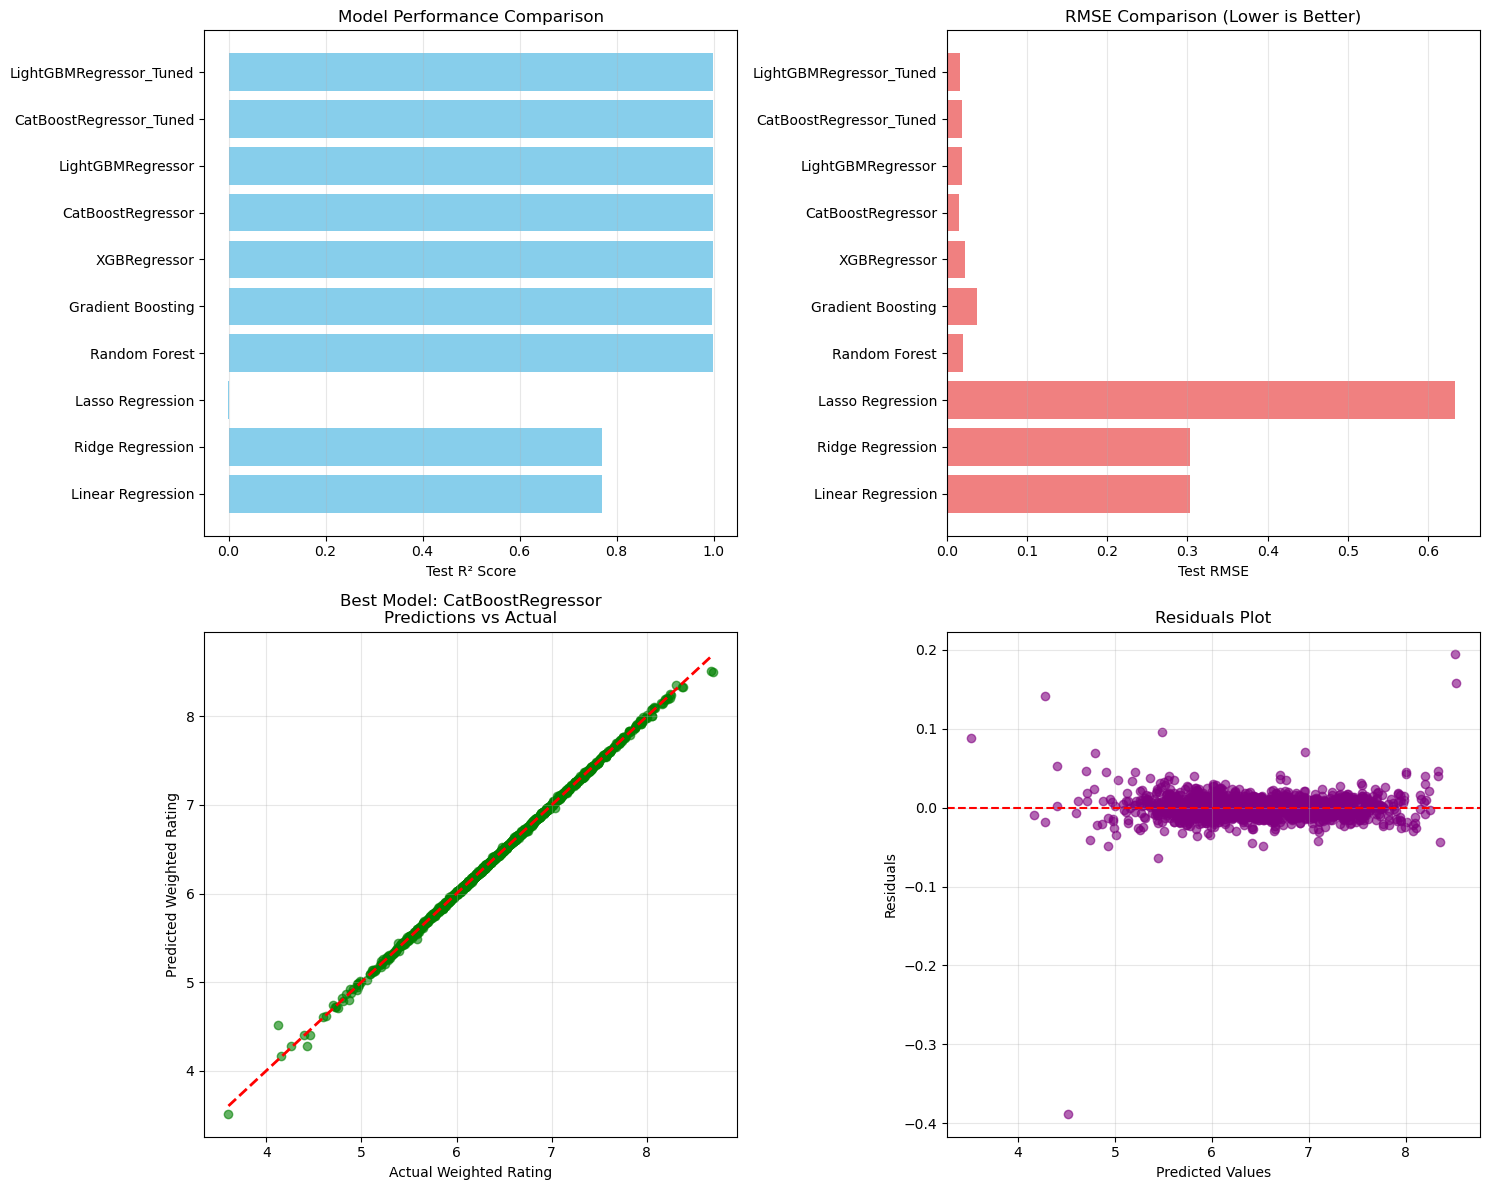


🔍 Top 15 Feature Importance (Random Forest):
                       Feature  Importance
4                 vote_average      0.8751
5                   vote_count      0.1237
39              profit_or_loss      0.0001
2                      revenue      0.0001
38  return_on_investment_ratio      0.0001
36       popularity_percentile      0.0001
0                      runtime      0.0001
1                       budget      0.0001
3                   popularity      0.0001
10                  num_genres      0.0001
31    num_production_companies      0.0001
32     main_production_country      0.0001
40              release_decade      0.0000
37                      season      0.0000
13                   Animation      0.0000


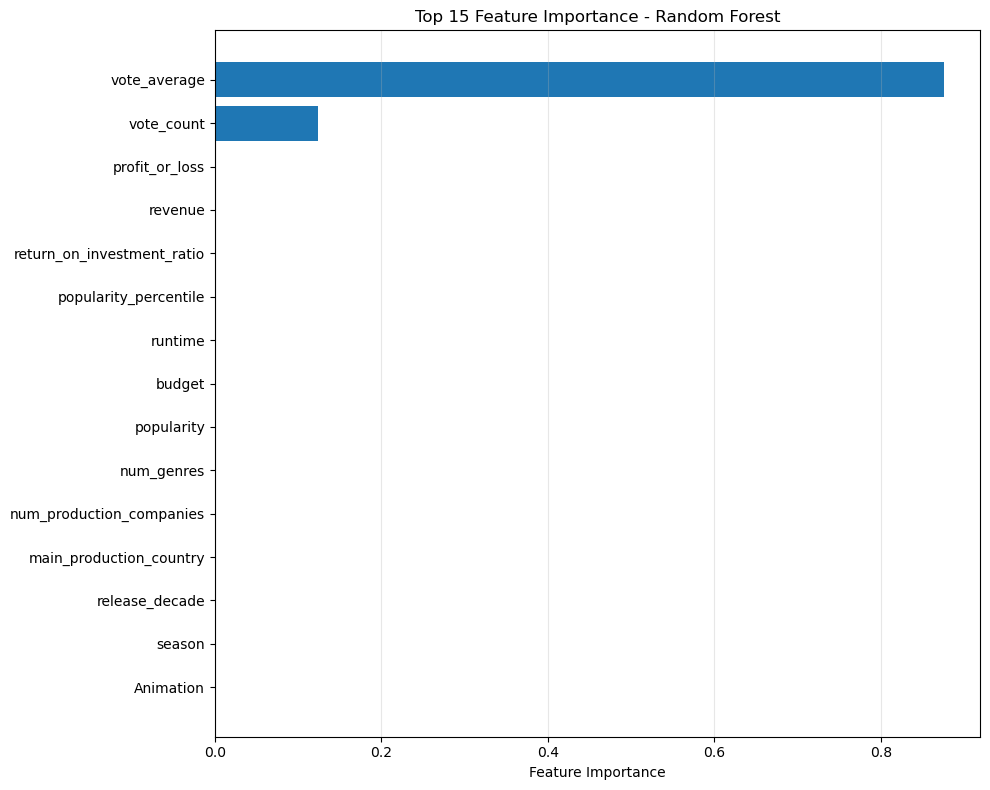

In [58]:
# lets clean the data and run the pipeline
df = data.drop(columns=['release_date', 'release_year', 'changed_title'])
predictor = MovieRatingPredictor(df)

# Run the complete pipeline
predictor.preprocess_data()
predictor.train_baseline_models()
predictor.tune_best_models()

# Evaluate and visualize results
results_df, best_model = predictor.evaluate_models()
predictor.plot_results()
predictor.get_feature_importance()

# Access the best model for future predictions
best_model_obj = predictor.results[best_model]['model']

## It is clear that the 'vote_avarage' is a false feature (high corrolotaion with the label)

🔄 Starting data preprocessing...
📊 Encoding categorical columns: ['main_production_country', 'season', 'release_decade']
🔢 Scaling numerical columns: 40 features
✅ Preprocessing complete!
📈 Training set: 7962 samples
📉 Test set: 1991 samples
🎯 Features: 40 columns

🤖 Training baseline models...
Training Linear Regression...
  ✅ Test RMSE: 0.4545, Test R²: 0.4841
Training Ridge Regression...
  ✅ Test RMSE: 0.4545, Test R²: 0.4841
Training Lasso Regression...
  ✅ Test RMSE: 0.6329, Test R²: -0.0004
Training Random Forest...
  ✅ Test RMSE: 0.3931, Test R²: 0.6140
Training Gradient Boosting...
  ✅ Test RMSE: 0.3856, Test R²: 0.6286
Training XGBRegressor...
  ✅ Test RMSE: 0.3894, Test R²: 0.6213
Training CatBoostRegressor...
  ✅ Test RMSE: 0.3627, Test R²: 0.6715
Training LightGBMRegressor...
  ✅ Test RMSE: 0.3714, Test R²: 0.6555

🔧 Starting hyperparameter tuning...
🏆 Tuning top models: ['CatBoostRegressor', 'LightGBMRegressor']

🎯 Tuning CatBoostRegressor...
  🎯 Best params: {'learning_ra

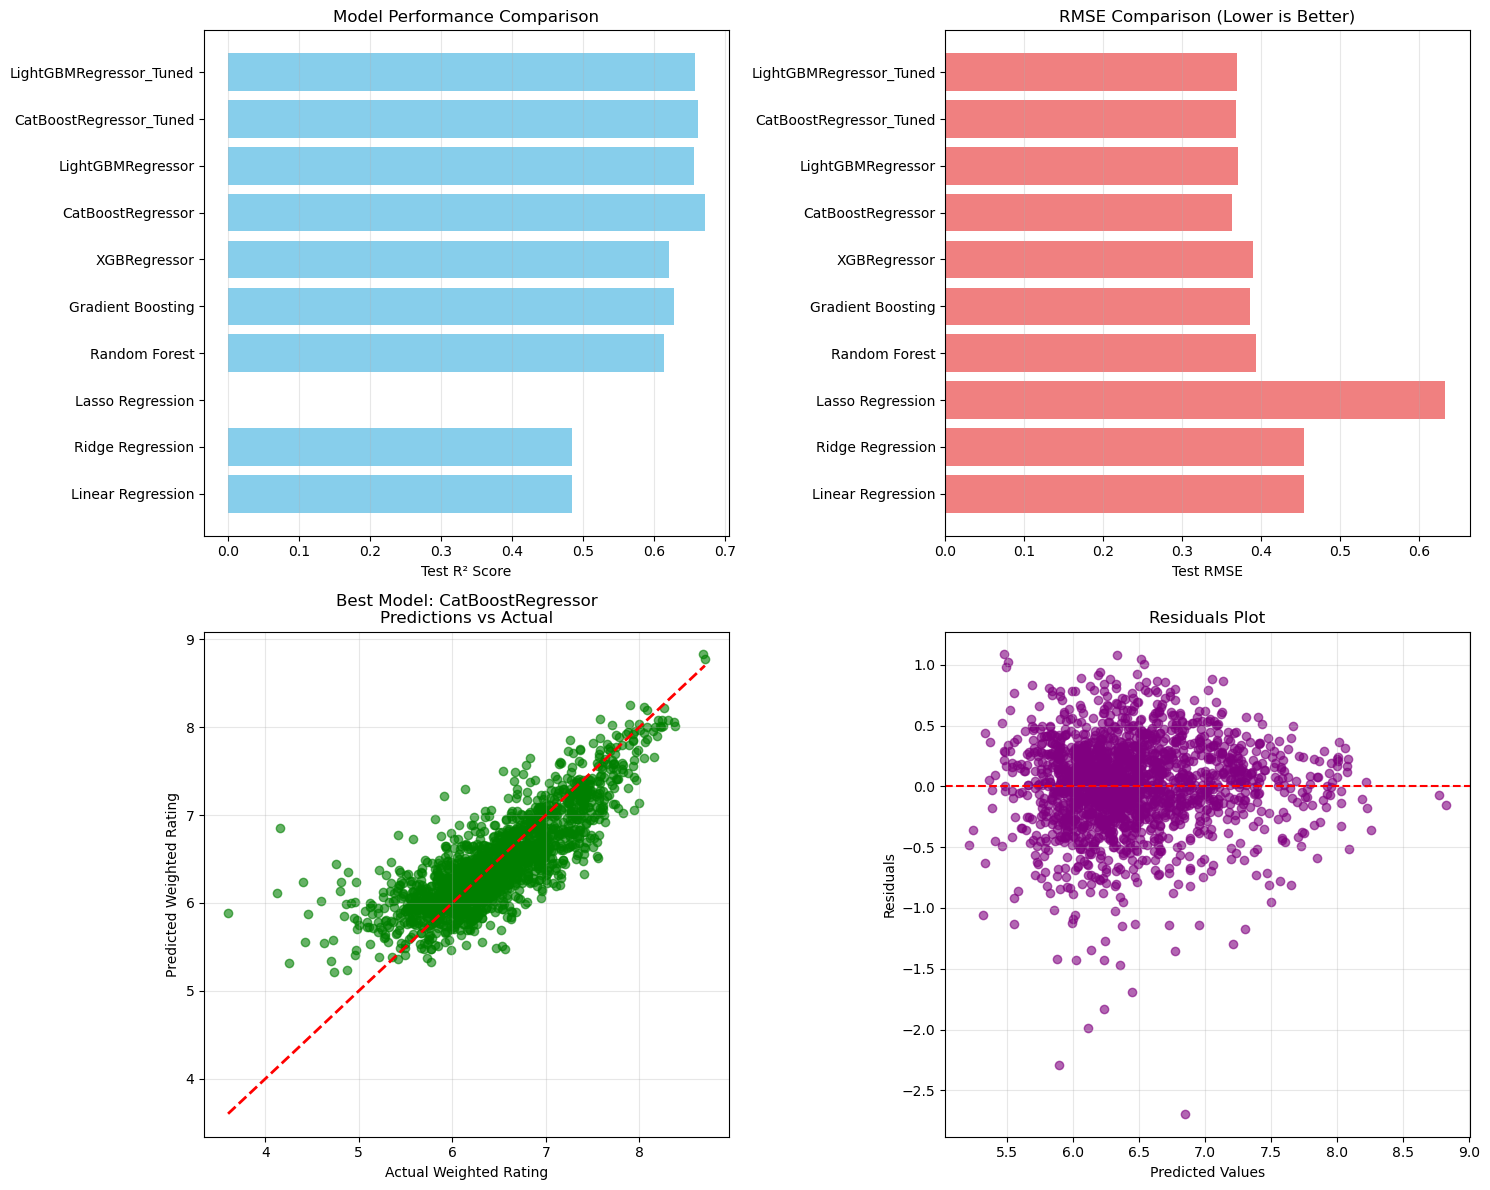


🔍 Top 15 Feature Importance (Gradient Boosting):
                       Feature  Importance
4                   vote_count      0.4194
0                      runtime      0.1131
1                       budget      0.1025
13                       Drama      0.0868
39              release_decade      0.0676
37  return_on_investment_ratio      0.0367
28                      Horror      0.0231
12                   Animation      0.0224
2                      revenue      0.0219
38              profit_or_loss      0.0203
34           is_english_spoken      0.0175
11                      Action      0.0109
35       popularity_percentile      0.0074
5        belongs_to_collection      0.0063
25                 Documentary      0.0062


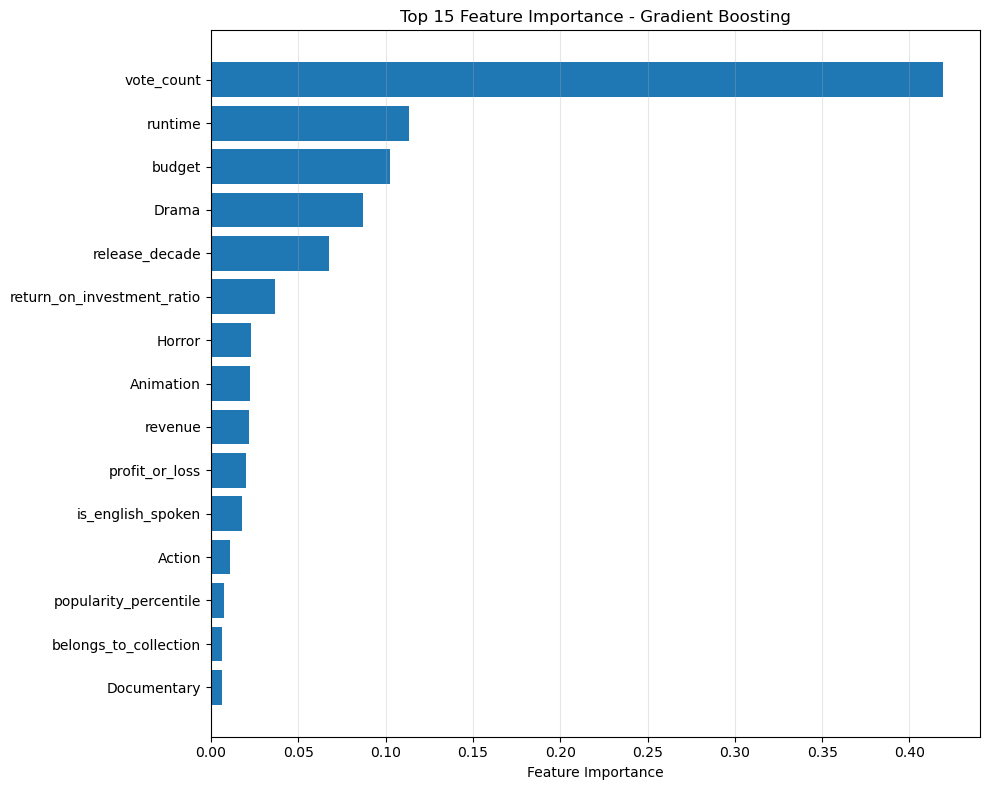

In [59]:
# lets clean the data and run the pipeline
df = data.drop(columns=['release_date', 'release_year', 'changed_title', 'vote_average'])
predictor = MovieRatingPredictor(df)

# Run the complete pipeline
predictor.preprocess_data()
predictor.train_baseline_models()
predictor.tune_best_models()

# Evaluate and visualize results
results_df, best_model = predictor.evaluate_models()
predictor.plot_results()
predictor.get_feature_importance()

# Access the best model for future predictions
best_model_obj = predictor.results[best_model]['model']

In [ ]:
# Load your dataset
df = pd.read_csv('your_movie_dataset.csv')

# Initialize anomaly detector
detector = MovieDataAnomalyDetector(df)

# Run complete pipeline
cleaned_data, anomaly_reports = detector.run_complete_pipeline(cleaning_strategy='moderate')

# Access cleaned data
print("Cleaned dataset shape:", cleaned_data.shape)
print("Cleaned dataset info:")
print(cleaned_data.info())


## Looks much better. lets make it even better with annomaly detection and clearing

# Classification

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9953 entries, 0 to 9952
Data columns (total 44 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   runtime                     9953 non-null   int64  
 1   budget                      9953 non-null   int64  
 2   revenue                     9953 non-null   int64  
 3   popularity                  9953 non-null   float64
 4   vote_average                9953 non-null   float64
 5   vote_count                  9953 non-null   int64  
 6   belongs_to_collection       9953 non-null   bool   
 7   has_tagline                 9953 non-null   bool   
 8   has_homepage                9953 non-null   bool   
 9   num_same_title              9953 non-null   int64  
 10  changed_title               9953 non-null   bool   
 11  num_genres                  9953 non-null   int64  
 12  Comedy                      9953 non-null   bool   
 13  Action                      9953 

🔄 Starting data preprocessing for classification...
📊 Identified 28 categorical and 13 numerical features.
✅ Preprocessing complete!
📈 Training set: 7962 samples
📉 Test set: 1991 samples
🎯 Features: 41 columns
🏷️ Target classes: 4

🤖 Training baseline classification models...
Training Logistic Regression...
  ✅ Test Accuracy: 0.5234, Test F1-Score: 0.5136
Training K-Nearest Neighbors...
  ✅ Test Accuracy: 0.4299, Test F1-Score: 0.4257
Training SVC...
  ✅ Test Accuracy: 0.5379, Test F1-Score: 0.5321
Training Random Forest...
  ✅ Test Accuracy: 0.5831, Test F1-Score: 0.5758
Training Gradient Boosting...
  ✅ Test Accuracy: 0.5952, Test F1-Score: 0.5876
Training XGBoost...
  ✅ Test Accuracy: 0.5937, Test F1-Score: 0.5888
Training LightGBM...
  ✅ Test Accuracy: 0.5902, Test F1-Score: 0.5853
Training CatBoost...
  ✅ Test Accuracy: 0.5967, Test F1-Score: 0.5914

📊 Model Evaluation Summary
                 Model  Accuracy  F1_Score
0             CatBoost    0.5967    0.5914
1              XGBo

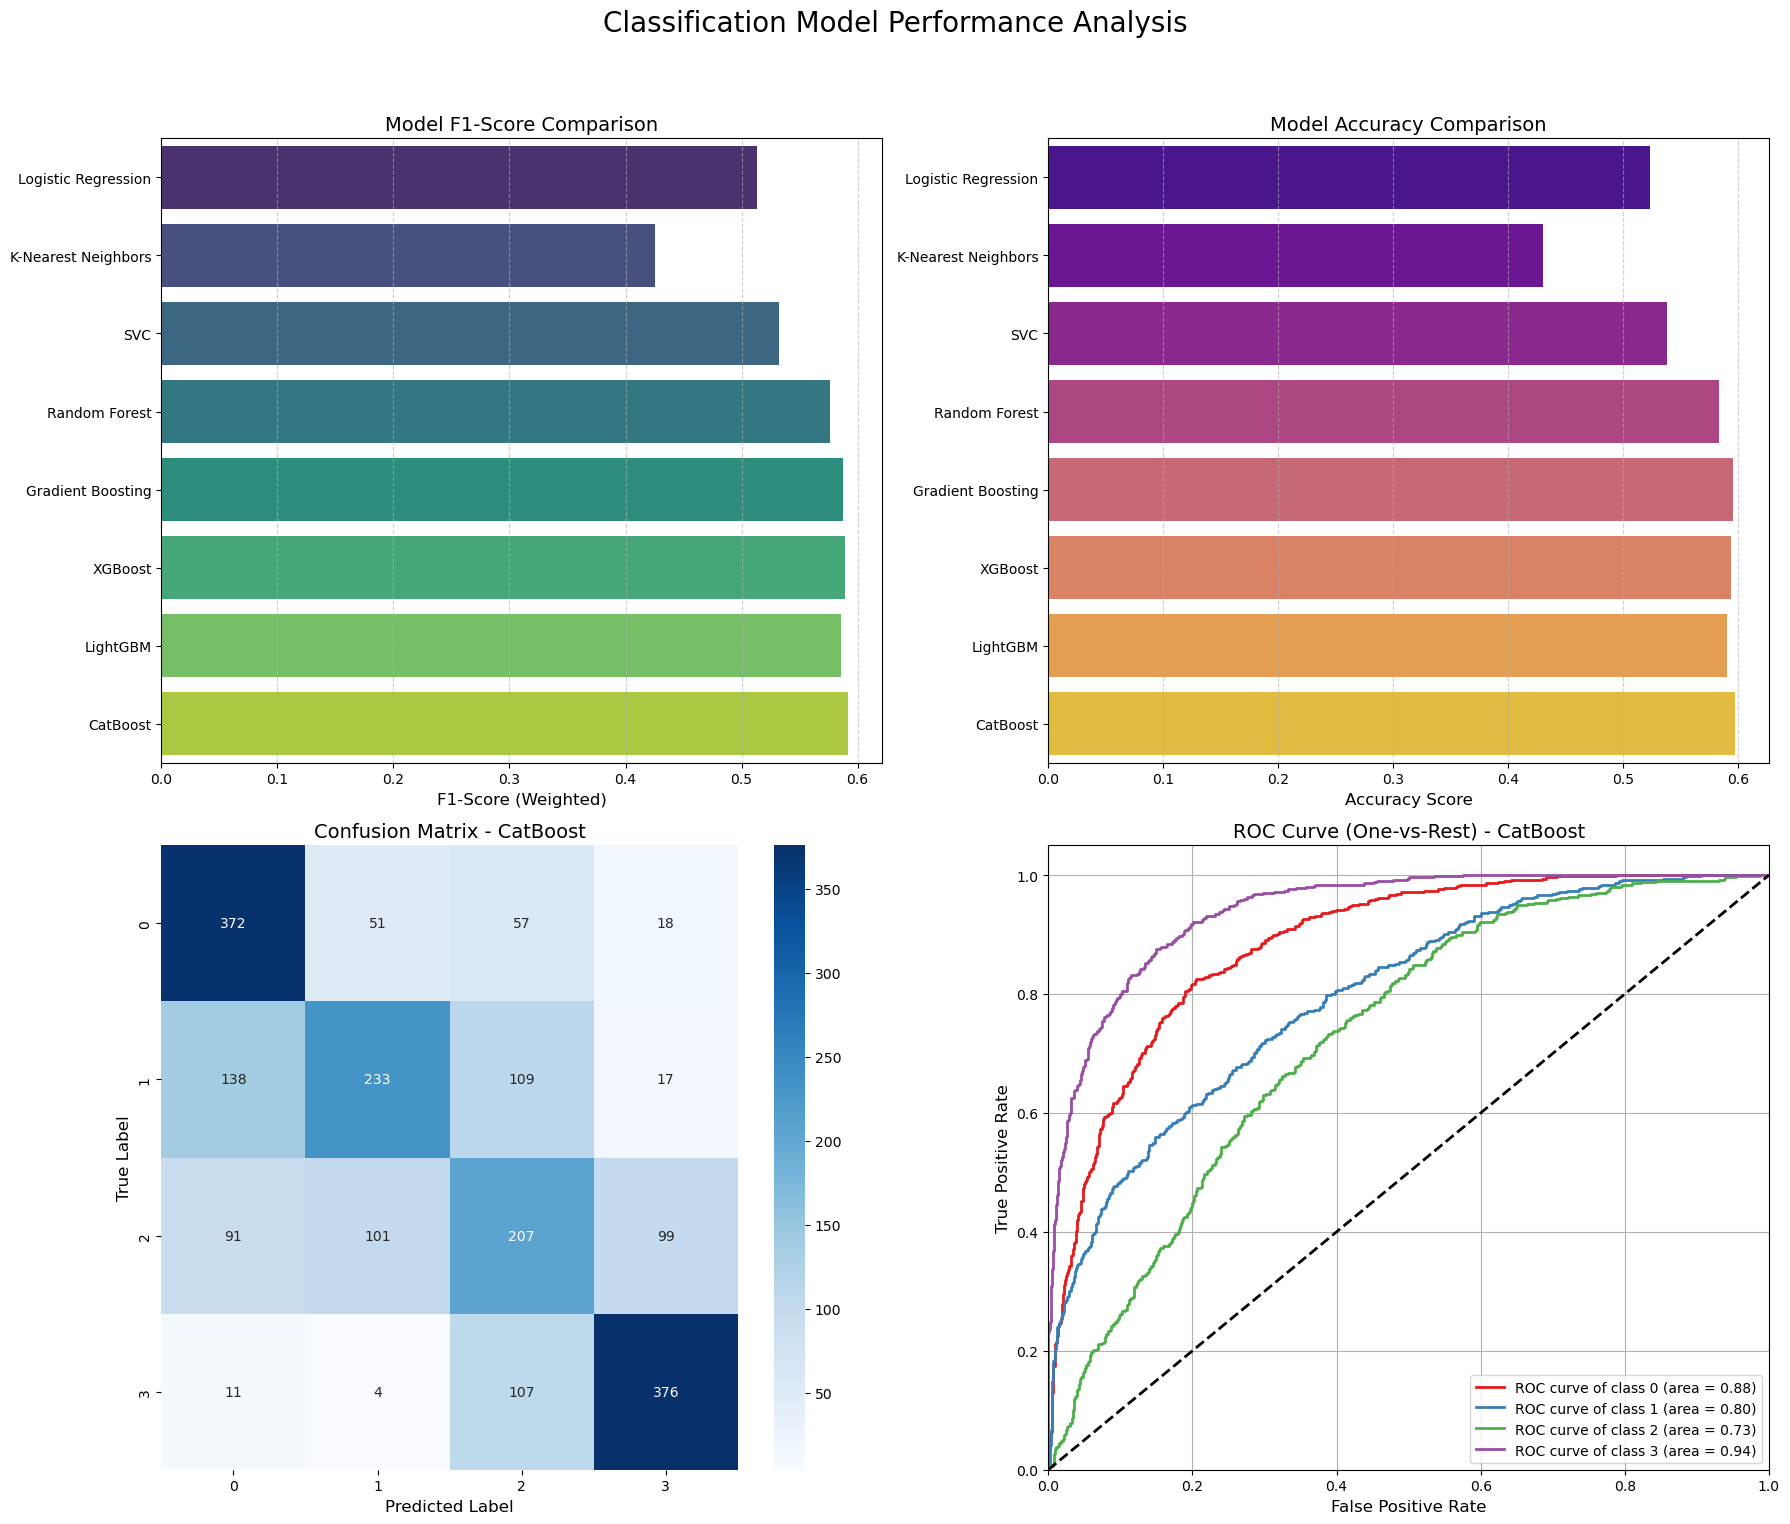

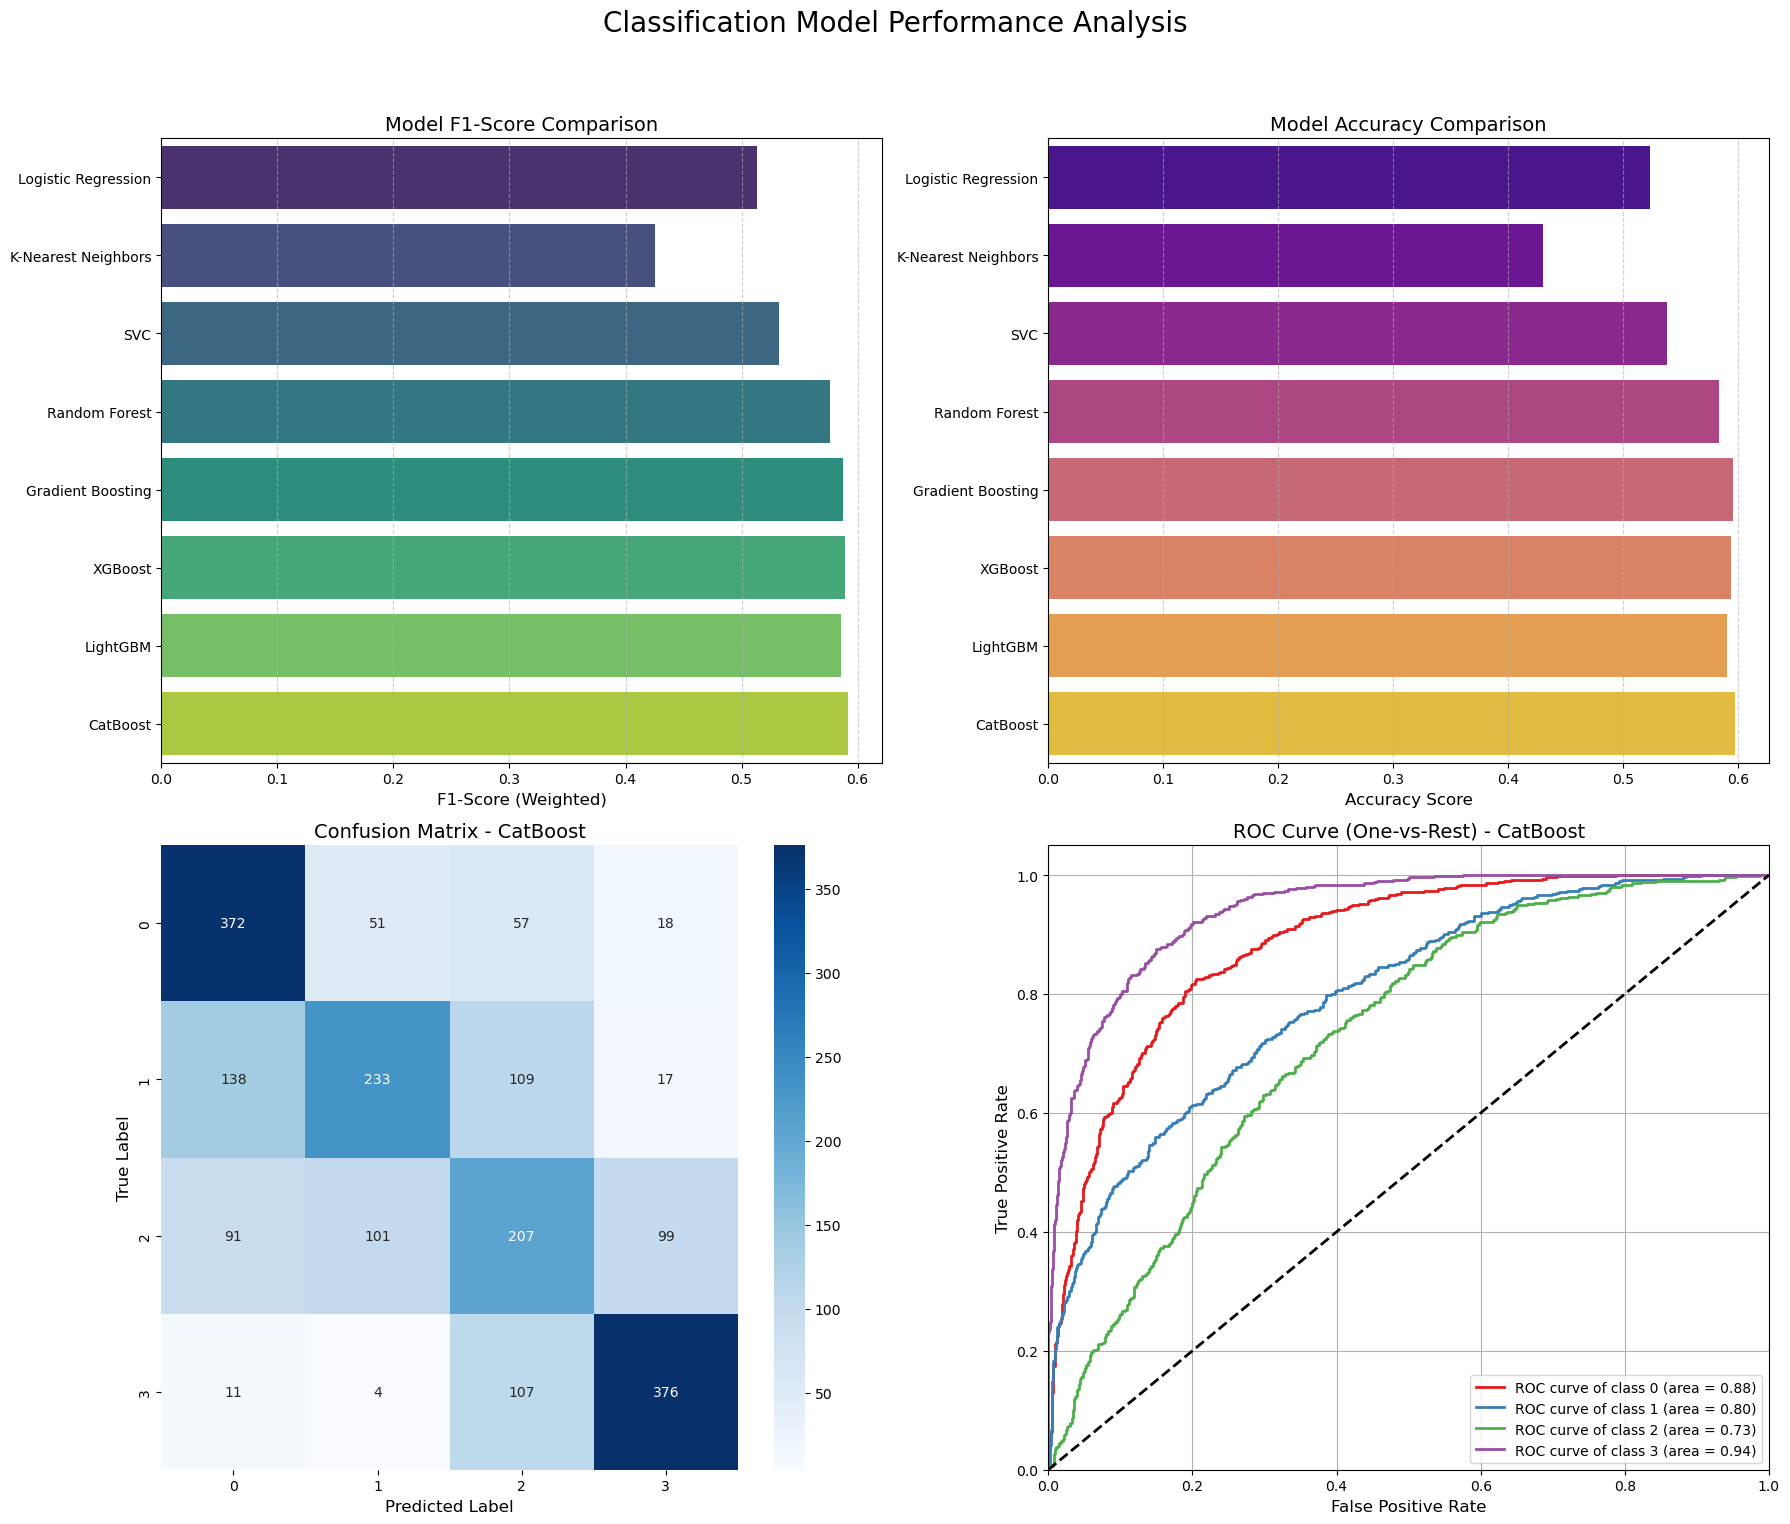

In [71]:
# # Option 1: Create binary classification from rating
df = data.drop(columns=['id', 'title', 'release_date', 'vote_average', 'profit_or_loss'])
# # df['weighted_rating'] = pd.cut(df['weighted_rating'], bins=10)
# classifier_pipeline = MovieRatingClassifier(df)
# classifier_pipeline.preprocess_data()
# classifier_pipeline.train_baseline_models()
# _, best_model = classifier_pipeline.evaluate_models()
# classifier_pipeline.plot_results()

classifier_pipeline = MovieRatingClassifier(df)
classifier_pipeline.preprocess_data()
classifier_pipeline.train_baseline_models()
_, best_model = classifier_pipeline.evaluate_models()
classifier_pipeline.plot_results()

🚀 Starting Anomaly Detection Pipeline...

Step 1: Detecting statistical outliers...
Step 2: Detecting business logic anomalies...
Step 3: Detecting multivariate outliers...
Step 4: Detecting data quality issues...
Step 5: Generating anomaly summary...
=== ANOMALY DETECTION SUMMARY ===
Original dataset shape: (9953, 47)
Total records: 9953

📊 STATISTICAL OUTLIERS:
  runtime:
    - Z-score outliers: 161
    - IQR outliers: 437
  budget:
    - Z-score outliers: 274
    - IQR outliers: 943
  revenue:
    - Z-score outliers: 213
    - IQR outliers: 1235
  popularity:
    - Z-score outliers: 101
    - IQR outliers: 689
  vote_average:
    - Z-score outliers: 143
    - IQR outliers: 246
  vote_count:
    - Z-score outliers: 255
    - IQR outliers: 1150
  num_same_title:
    - Z-score outliers: 552
    - IQR outliers: 552
  num_genres:
    - Z-score outliers: 72
    - IQR outliers: 407
  num_production_companies:
    - Z-score outliers: 171
    - IQR outliers: 424
  num_production_countries:
 

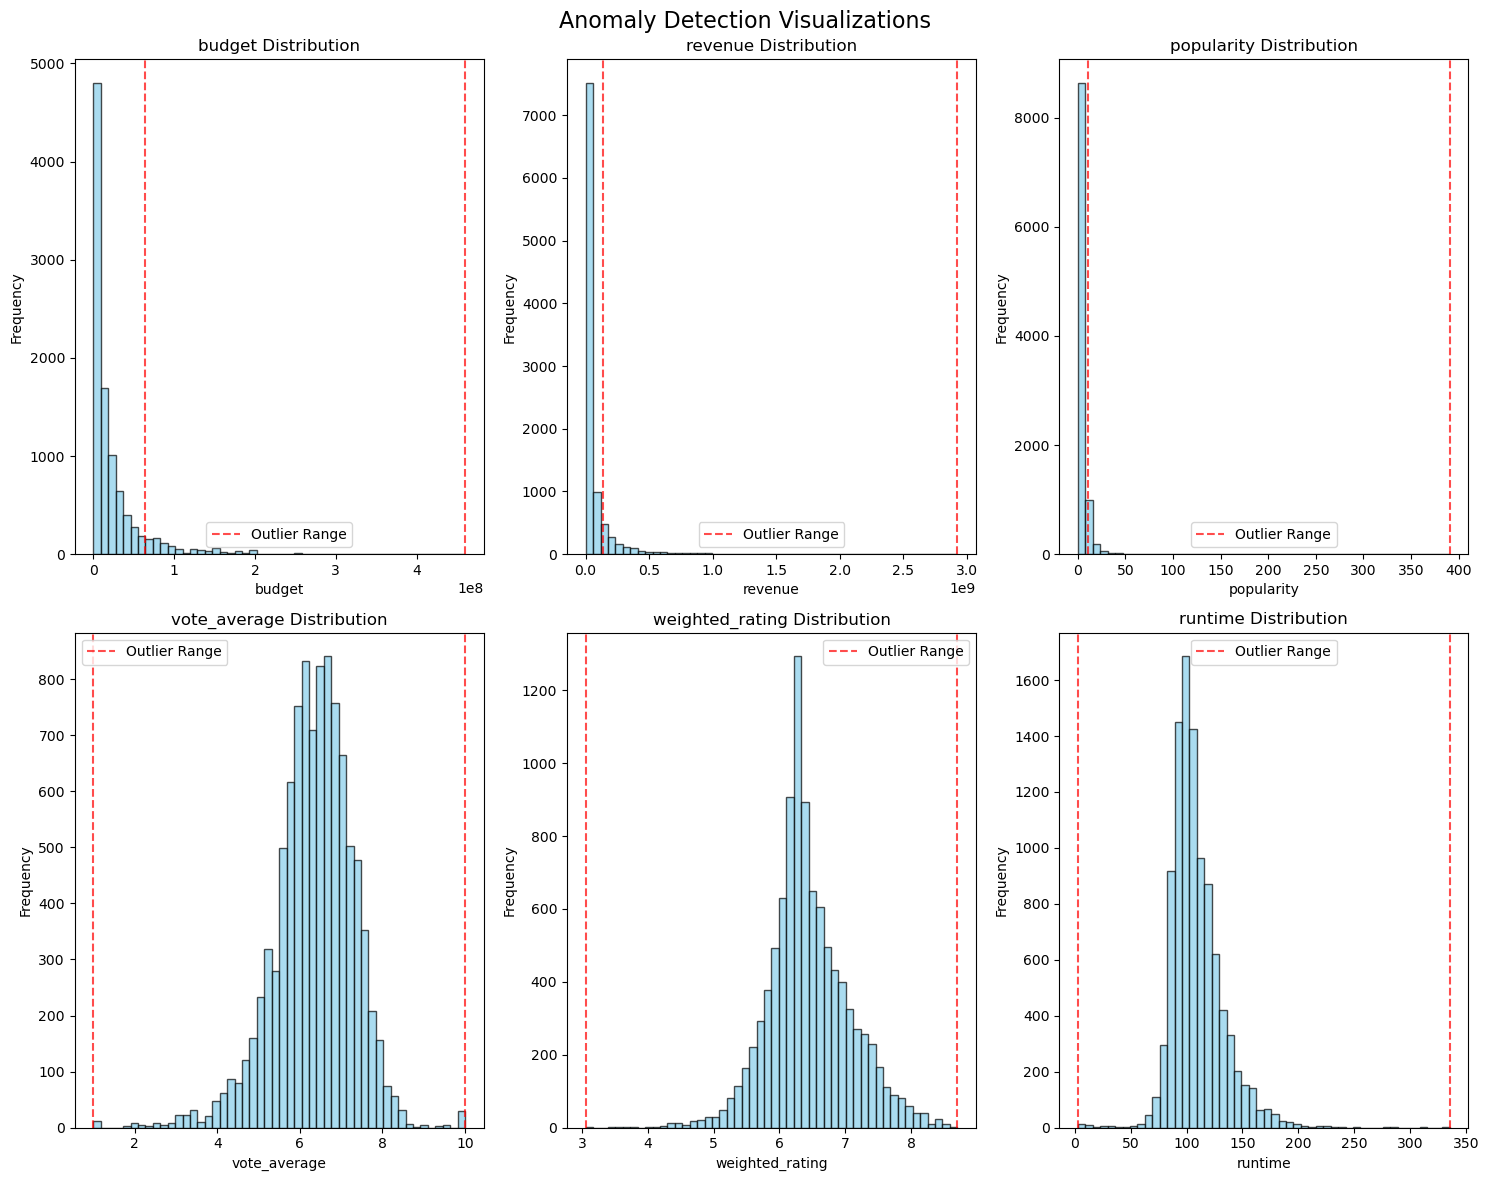

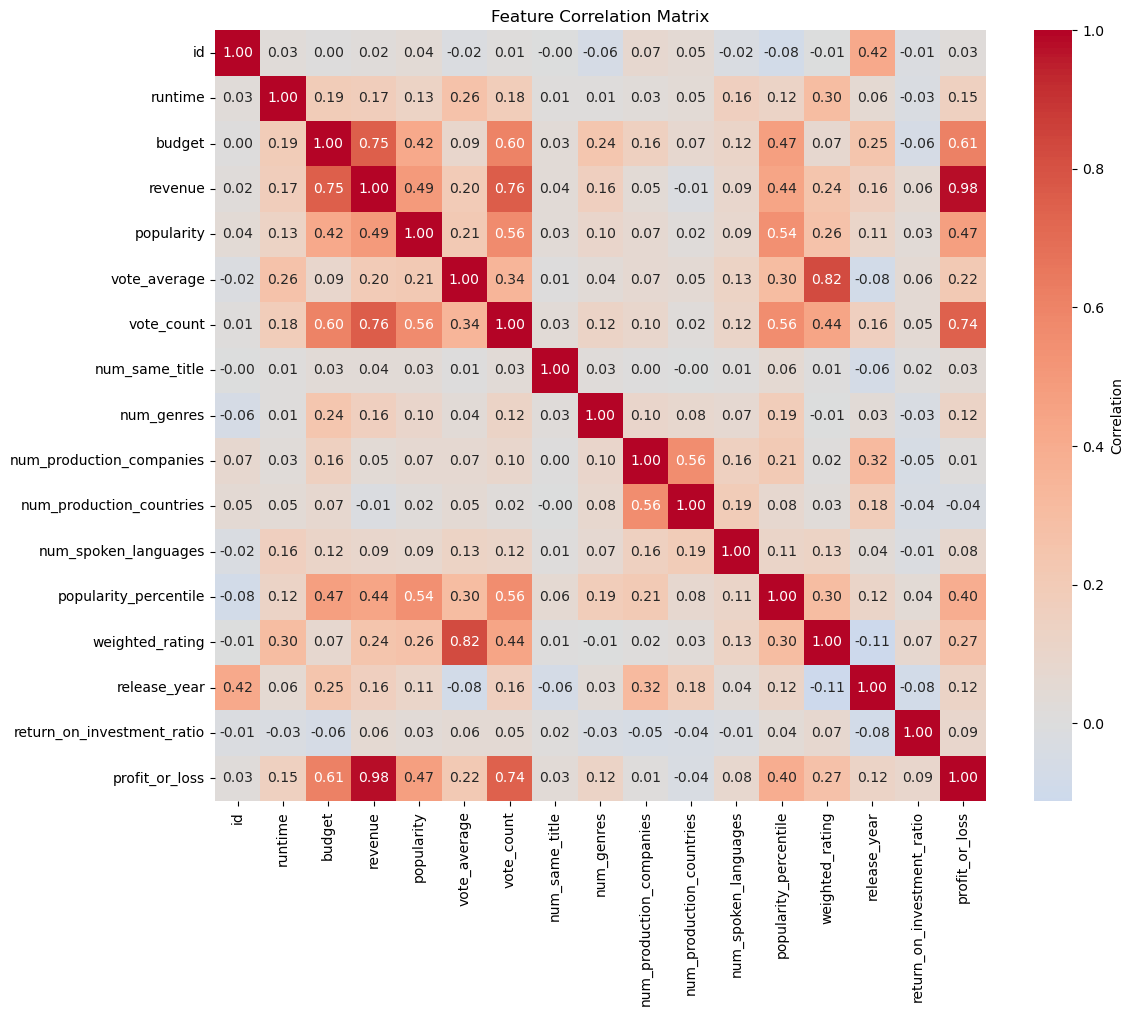

✅ Anomaly detection pipeline completed!


(          id                     title  runtime release_date    budget  \
 0          5                Four Rooms       98   1995-12-09   4000000   
 1          6            Judgment Night      109   1993-10-15  21000000   
 2         11                 Star Wars      121   1977-05-25  11000000   
 3         12              Finding Nemo      100   2003-05-30  94000000   
 4         13              Forrest Gump      142   1994-06-23  55000000   
 ...      ...                       ...      ...          ...       ...   
 9914  502416                        Ma       99   2019-05-29   5000000   
 9915  502682                 Book Club      104   2018-05-18  10000000   
 9916  502913                  Swingers       97   2018-03-28    100000   
 9917  503115                      Azar       93   2017-02-01     10000   
 9918  503314  Dragon Ball Super: Broly       99   2018-12-14   1000000   
 
         revenue  popularity  vote_average  vote_count  belongs_to_collection  \
 0       4257354 

In [ ]:
MovieDataAnomalyDetector(df).run_complete_pipeline(cleaning_strategy='moderate')